In [1]:
# === Cell 0 — Config & imports ===
import os, io, time, zipfile, requests, warnings
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

warnings.filterwarnings("ignore")

# Project paths (Windows)
PROJ_ROOT = Path(r"C:\Users\Admin\Desktop\phongvan")
DUMP_ROOT = PROJ_ROOT / "data" / "crypto_data"     # nơi lưu toàn bộ dữ liệu local
(DUMP_ROOT / "processed").mkdir(parents=True, exist_ok=True)

# Crawl config
ASSET_CLASS = "um"          # USDT-M Futures
DATA_FREQUENCY = "1d"
TODAY = datetime.utcnow().date()
START_DATE = (TODAY - timedelta(days=5*365)).strftime("%Y-%m-%d")
END_DATE   = TODAY.strftime("%Y-%m-%d")

SYMBOLS = ["BTCUSDT","ETHUSDT","BNBUSDT","XRPUSDT","SOLUSDT","TRXUSDT","DOGEUSDT"]

print(f"Dump root: {DUMP_ROOT}")
print(f"Range: {START_DATE} → {END_DATE} | Asset: {ASSET_CLASS} | Freq: {DATA_FREQUENCY}")
print("Symbols:", SYMBOLS)

# Optional: nhẹ nhàng hơn khi bị rate-limit
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "portfolio-test/1.0"})


Dump root: C:\Users\Admin\Desktop\phongvan\data\crypto_data
Range: 2020-10-18 → 2025-10-17 | Asset: um | Freq: 1d
Symbols: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'SOLUSDT', 'TRXUSDT', 'DOGEUSDT']


In [2]:
# === Cell 1 — CSV utils ===

def detect_ts_unit(ts):
    n = len(str(int(ts)))
    if n == 13: return "ms"
    if n == 16: return "us"
    return "ms"

def to_datetime(ts):
    return pd.to_datetime(ts, unit=detect_ts_unit(ts), errors="coerce")

BINANCE_COLS = [
    "open_time","Open","High","Low","Close","volume",
    "close_time","quote_asset_volume","number_of_trades",
    "taker_buy_base_asset_volume","taker_buy_quote_asset_volume","ignore"
]

def read_kline_csv(fp: str | Path) -> pd.DataFrame:
    df = pd.read_csv(fp)
    df.columns = BINANCE_COLS
    df["open_time"]  = df["open_time"].apply(to_datetime)
    df["close_time"] = df["close_time"].apply(to_datetime)
    return df

def list_csvs(directory: Path):
    if not directory.exists():
        return []
    return [directory / f for f in os.listdir(directory) if str(f).endswith(".csv")]


In [6]:
# === Cell 2 — Robust HTTP session + REST + Vision (no urllib) ===
import io, time, zipfile, requests
from requests.adapters import HTTPAdapter, Retry

# Session robust với retry & backoff để chống 5xx/429/tls trục trặc tạm thời
SESSION = requests.Session()
retries = Retry(
    total=8, connect=8, read=8, status=8,
    status_forcelist=[429, 500, 502, 503, 504],
    backoff_factor=0.5, raise_on_status=False
)
SESSION.mount("https://", HTTPAdapter(max_retries=retries))
SESSION.headers.update({"User-Agent": "portfolio-test/1.0"})

FAPI_ENDPOINTS = [
    "https://fapi.binance.com",
    "https://fapi1.binance.com",
    "https://fapi.binancefuture.com",
]

def _to_millis(dt_str_YYYY_MM_DD):
    from datetime import datetime as _dt
    return int(_dt.strptime(dt_str_YYYY_MM_DD, "%Y-%m-%d").timestamp() * 1000)

def fetch_klines_rest_multi(symbol, interval="1d", start_date=START_DATE, end_date=END_DATE, limit=1500, sleep_sec=0.2):
    """REST đa endpoint (requests + retry). Trả DataFrame columns=BINANCE_COLS hoặc None."""
    start_ms = _to_millis(start_date)
    end_ms   = _to_millis(end_date)
    out = []
    for base in FAPI_ENDPOINTS:
        try:
            cur = start_ms
            tmp = []
            while True:
                params = {"symbol": symbol, "interval": interval, "startTime": cur, "endTime": end_ms, "limit": limit}
                r = SESSION.get(f"{base}/fapi/v1/klines", params=params, timeout=25)
                # 451 hoặc lỗi khác -> thử endpoint kế
                if r.status_code in (451, 403):
                    raise requests.HTTPError(f"{r.status_code} from {base}")
                r.raise_for_status()
                data = r.json()
                if not data:
                    break
                tmp.extend(data)
                last_open = data[-1][0]
                next_ms = last_open + 1
                if next_ms >= end_ms:
                    break
                cur = next_ms
                time.sleep(sleep_sec)
            if tmp:
                out = tmp
                print(f"  ✅ REST ok on {base}, rows={len(tmp)}")
                break
        except Exception as e:
            print(f"  ⚠️ REST {base} error: {type(e).__name__}: {e}")
            continue

    if not out:
        return None

    df = pd.DataFrame(out, columns=BINANCE_COLS)
    df["open_time"]  = df["open_time"].apply(to_datetime)
    df["close_time"] = df["close_time"].apply(to_datetime)
    return df

VISION_BASE = "https://data.binance.vision"

def month_iter(start_date_str, end_date_str):
    s = pd.to_datetime(start_date_str).date()
    e = pd.to_datetime(end_date_str).date()
    y, m = s.year, s.month
    while (y < e.year) or (y == e.year and m <= e.month):
        yield y, m
        m = 1 if m == 12 else m + 1
        if m == 1: y += 1

def download_month_zip(symbol, interval="1d", yyyy=2020, mm=1, asset_class=ASSET_CLASS, dump_root=DUMP_ROOT):
    """Tải zip monthly qua requests + retry; giải nén vào daily/klines/<symbol>/<interval>/"""
    file_name = f"{symbol}-{interval}-{yyyy}-{mm:02d}.zip"
    url = f"{VISION_BASE}/data/futures/{asset_class}/monthly/klines/{symbol}/{interval}/{file_name}"
    r = SESSION.get(url, timeout=40)
    if r.status_code == 404:
        return False
    r.raise_for_status()
    z = zipfile.ZipFile(io.BytesIO(r.content))
    out_dir = dump_root / f"{asset_class}/daily/klines/{symbol}/{interval}"
    out_dir.mkdir(parents=True, exist_ok=True)
    z.extractall(out_dir)
    return True

def download_vision_monthly_range(symbol, start_date=START_DATE, end_date=END_DATE, interval="1d"):
    ok_any = False
    for y, m in month_iter(start_date, end_date):
        try:
            ok = download_month_zip(symbol, interval=interval, yyyy=y, mm=m)
            if ok:
                ok_any = True
                print(f"  ✅ vision: {symbol} {y}-{m:02d}")
            else:
                print(f"  ⛔ vision: {symbol} {y}-{m:02d} (404)")
        except Exception as e:
            print(f"  ⚠️ vision error {symbol} {y}-{m:02d}: {type(e).__name__}: {e}")
            time.sleep(0.25)
    return ok_any


In [7]:
# === Cell 3 — Master downloader (no BinanceDataDumper) ===

def download_ticker_no_dumper(ticker, date_start, date_end, data_frequency=DATA_FREQUENCY, asset_class=ASSET_CLASS):
    # 1) REST đa endpoint trước
    try:
        df = fetch_klines_rest_multi(
            ticker, interval=data_frequency,
            start_date=date_start, end_date=date_end
        )
        if df is not None and not df.empty:
            out_dir = DUMP_ROOT / f"{asset_class}/daily/klines/{ticker}/{data_frequency}"
            out_dir.mkdir(parents=True, exist_ok=True)
            out_csv = out_dir / f"REST_{date_start}_{date_end}.csv"
            df.to_csv(out_csv, index=False)
            print(f"  ✅ REST saved: {out_csv.name} ({len(df)} rows)")
            return
        else:
            print("  ℹ️ REST returned no data – trying vision monthly …")
    except Exception as e:
        print(f"⚠️ REST error ({ticker}): {type(e).__name__}: {e} → try vision monthly")

    # 2) Vision monthly ZIP
    ok_any = download_vision_monthly_range(
        ticker, start_date=date_start, end_date=date_end, interval=data_frequency
    )
    if not ok_any:
        raise RuntimeError(f"Không tải được {ticker} bằng REST lẫn vision monthly.")
    else:
        print(f"  ✅ vision monthly downloaded CSVs for {ticker}")

# 👉 Chạy thử 1 mã trước (BTCUSDT) để xác nhận
print(f"\n⬇️ Smoke test BTCUSDT ({ASSET_CLASS}, {DATA_FREQUENCY}) {START_DATE} → {END_DATE}")
download_ticker_no_dumper("BTCUSDT", START_DATE, END_DATE, DATA_FREQUENCY, ASSET_CLASS)

# Nếu OK, chạy tất cả:
for sym in SYMBOLS:
    if sym == "BTCUSDT":  # đã tải ở trên
        continue
    print(f"\n⬇️ Downloading {sym} ({ASSET_CLASS}, {DATA_FREQUENCY}) {START_DATE} → {END_DATE}")
    download_ticker_no_dumper(sym, START_DATE, END_DATE, DATA_FREQUENCY, ASSET_CLASS)

print("\n🎉 Done crawling raw CSVs (no dumper).")



⬇️ Smoke test BTCUSDT (um, 1d) 2020-10-18 → 2025-10-17
  ✅ REST ok on https://fapi.binance.com, rows=1825
  ✅ REST saved: REST_2020-10-18_2025-10-17.csv (1825 rows)

⬇️ Downloading ETHUSDT (um, 1d) 2020-10-18 → 2025-10-17
  ✅ REST ok on https://fapi.binance.com, rows=1825
  ✅ REST saved: REST_2020-10-18_2025-10-17.csv (1825 rows)

⬇️ Downloading BNBUSDT (um, 1d) 2020-10-18 → 2025-10-17
  ✅ REST ok on https://fapi.binance.com, rows=1825
  ✅ REST saved: REST_2020-10-18_2025-10-17.csv (1825 rows)

⬇️ Downloading XRPUSDT (um, 1d) 2020-10-18 → 2025-10-17
  ✅ REST ok on https://fapi.binance.com, rows=1825
  ✅ REST saved: REST_2020-10-18_2025-10-17.csv (1825 rows)

⬇️ Downloading SOLUSDT (um, 1d) 2020-10-18 → 2025-10-17
  ✅ REST ok on https://fapi.binance.com, rows=1825
  ✅ REST saved: REST_2020-10-18_2025-10-17.csv (1825 rows)

⬇️ Downloading TRXUSDT (um, 1d) 2020-10-18 → 2025-10-17
  ✅ REST ok on https://fapi.binance.com, rows=1825
  ✅ REST saved: REST_2020-10-18_2025-10-17.csv (1825 rows)

In [14]:
# === Cell 4 — Build panel from CSVs (RAW, robust reader) ===
from pathlib import Path
import pandas as pd, numpy as np, os

ASSET_CLASS = "um"
DATA_FREQUENCY = "1d"
SYMBOLS = ["BTCUSDT","ETHUSDT","BNBUSDT","XRPUSDT","SOLUSDT","TRXUSDT","DOGEUSDT"]

BINANCE_COLS = [
    "open_time","Open","High","Low","Close","volume",
    "close_time","quote_asset_volume","number_of_trades",
    "taker_buy_base_asset_volume","taker_buy_quote_asset_volume","ignore"
]

def _robust_parse_time_col(s):
    """Trả về pd.Series datetime từ cột open_time/close_time:
       - Nếu là số hoặc chuỗi số -> coi là epoch (ms) trước, nếu fail thử (us).
       - Nếu vẫn NaT -> parse như chuỗi datetime ISO.
    """
    # 1) numeric direct?
    if np.issubdtype(s.dtype, np.number):
        dt = pd.to_datetime(s, unit="ms", errors="coerce")
        if dt.isna().all():
            dt = pd.to_datetime(s, unit="us", errors="coerce")
        if dt.isna().all():
            dt = pd.to_datetime(s, errors="coerce")
        return dt

    # 2) try numeric conversion
    s_num = pd.to_numeric(s, errors="coerce")
    dt = pd.to_datetime(s_num, unit="ms", errors="coerce")
    if dt.isna().all():
        dt = pd.to_datetime(s_num, unit="us", errors="coerce")

    # 3) fallback: parse as datetime string
    mask = dt.isna()
    if mask.any():
        dt_loc = pd.to_datetime(s[mask], errors="coerce")
        dt = dt.copy()
        dt.loc[mask] = dt_loc
    return dt

def read_kline_csv(fp: Path) -> pd.DataFrame:
    """Đọc 1 CSV kline từ REST hoặc vision, chịu mọi định dạng tên cột/kiểu thời gian."""
    df = pd.read_csv(fp)

    # Chuẩn hóa cột: nếu không đủ 12 cột đặt tên theo BINANCE_COLS (nhiều file vision không có header)
    if df.shape[1] >= 12:
        df = df.iloc[:, :12].copy()
        df.columns = BINANCE_COLS
    else:
        # Nếu file đã có tên cột chuẩn thì giữ; nếu không thì raise sớm
        need = {"open_time","Open","High","Low","Close","volume","close_time"}
        if not need.issubset(set(df.columns)):
            raise ValueError(f"File {fp.name} không đúng định dạng kline (cột thiếu).")

    # Parse thời gian robust
    df["open_time"]  = _robust_parse_time_col(df["open_time"])
    df["close_time"] = _robust_parse_time_col(df["close_time"])

    # Loại hàng invalid time
    df = df[df["open_time"].notna()].copy()
    df = df.sort_values("open_time").drop_duplicates(subset=["open_time"])
    return df

def list_csvs(directory: Path):
    return sorted([directory / f for f in os.listdir(directory) if f.lower().endswith(".csv")]) if directory.exists() else []

frames = {}
for sym in SYMBOLS:
    d1 = DUMP_ROOT / f"{ASSET_CLASS}/daily/klines/{sym}/{DATA_FREQUENCY}"
    d2 = DUMP_ROOT / f"{ASSET_CLASS}/monthly/klines/{sym}/{DATA_FREQUENCY}"
    files = list_csvs(d1) + list_csvs(d2)
    if not files:
        print(f"❗ Không tìm thấy CSV cho {sym}")
        continue

    dfs = []
    for fp in files:
        try:
            dfs.append(read_kline_csv(fp))
        except Exception as e:
            print(f"⚠️ Bỏ qua file lỗi {fp.name}: {e}")

    if not dfs:
        print(f"⚠️ {sym}: không có file hợp lệ sau khi lọc.")
        continue

    df_all = pd.concat(dfs, ignore_index=True)
    df = (df_all[["open_time","Open","High","Low","Close","volume"]]
           .rename(columns={"open_time":"date"})
           .set_index("date"))
    # đảm bảo index datetime & sort
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[df.index.notna()].sort_index()

    if df.empty:
        print(f"⚠️ {sym} rỗng sau gộp — bỏ qua.")
        continue

    frames[sym] = df

if not frames:
    raise RuntimeError("Không có dữ liệu CSV hợp lệ để build panel. Kiểm tra thư mục tải ở Cell 3.")

# Panel OHLCV: MultiIndex columns (symbol, field)
panel = pd.concat(frames, axis=1).sort_index()
panel.columns = pd.MultiIndex.from_tuples(panel.columns)

PROCESSED.mkdir(parents=True, exist_ok=True)
panel_path = PROCESSED / "um_1d_OHLCV_5y.RAW.parquet"
panel.to_parquet(panel_path)

# Close-only (wide) + CSV có cột date chuẩn
close_wide = pd.concat({sym: frames[sym]["Close"] for sym in frames}, axis=1)
close_wide.index = pd.to_datetime(close_wide.index)
close_csv = PROCESSED / "um_close_only_1d_5y.RAW.csv"
close_wide.to_csv(close_csv, index=True, index_label="date", date_format="%Y-%m-%d", encoding="utf-8")

print("✅ Saved panel RAW:", panel_path)
print("✅ Saved close-only RAW:", close_csv)
print("Range:", close_wide.index.min().date(), "→", close_wide.index.max().date())
display(close_wide.head())


✅ Saved panel RAW: C:\Users\Admin\Desktop\phongvan\data\crypto_data\processed\um_1d_OHLCV_5y.RAW.parquet
✅ Saved close-only RAW: C:\Users\Admin\Desktop\phongvan\data\crypto_data\processed\um_close_only_1d_5y.RAW.csv
Range: 2020-10-18 → 2025-10-16


,BTCUSDT,ETHUSDT,BNBUSDT,XRPUSDT,SOLUSDT,TRXUSDT,DOGEUSDT
date,,,,,,,
2020-10-18,11501.10,378.29,30.599,0.2422,2.2186,0.02592,0.002588
2020-10-19,11745.00,379.47,29.899,0.2457,2.0578,0.02589,0.002593
2020-10-20,11900.03,368.74,28.831,0.2434,1.8905,0.02593,0.002594
2020-10-21,12796.07,390.96,29.734,0.2511,1.8933,0.02669,0.002627
2020-10-22,12968.87,414.39,30.663,0.2572,1.9619,0.02710,0.002649


In [15]:
# === Cell 5 — Clean & Align (robust + QC trực quan) ===
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# 0) Load panel RAW (tự dò tên)
candidates = [
    PROCESSED / "um_1d_OHLCV_5y.RAW.parquet",
    PROCESSED / "um_1d_OHLCV_5y.parquet",
]
panel_path = next((p for p in candidates if p.exists()), None)
assert panel_path is not None, "Không tìm thấy panel RAW. Hãy chạy Cell 4 trước."

panel_raw = pd.read_parquet(panel_path)
if not pd.api.types.is_datetime64_any_dtype(panel_raw.index):
    panel_raw.index = pd.to_datetime(panel_raw.index, errors="coerce")
panel_raw = panel_raw[panel_raw.index.notna()].sort_index()
assert not panel_raw.empty, "panel_raw rỗng sau chuẩn hóa index — kiểm tra Cell 4."

symbols = sorted({c[0] for c in panel_raw.columns})

# --------- QC trước khi clean ----------
close_raw = panel_raw.xs("Close", axis=1, level=1)
nan_pct_raw = close_raw.isna().mean().rename("NaN% (raw)")
range_raw = pd.DataFrame({
    "first": close_raw.apply(lambda s: s.first_valid_index()),
    "last":  close_raw.apply(lambda s: s.last_valid_index()),
    "n_non_na": close_raw.notna().sum(),
    "NaN% (raw)": nan_pct_raw
}).loc[symbols]
print("=== QC trước clean ===")
display(range_raw)

px.bar(nan_pct_raw.sort_values(ascending=False),
       title="Tỉ lệ NaN theo mã (Close, TRƯỚC clean)").show()

# 1) Hàm clean 1 symbol
def clean_one_symbol(df_ohlcv: pd.DataFrame) -> pd.DataFrame:
    df = df_ohlcv.copy()
    # a) loại giá <=0, volume <0
    for col in ["Open","High","Low","Close"]:
        df.loc[df[col] <= 0, col] = np.nan
    df.loc[df["volume"] < 0, "volume"] = np.nan
    # b) High/Low consistency
    max_oc = df[["Open","Close"]].max(axis=1)
    min_oc = df[["Open","Close"]].min(axis=1)
    bad = (df["High"] < max_oc) | (df["Low"] > min_oc)
    if bad.any():
        df.loc[bad, ["Open","High","Low","Close"]] = np.nan
    # c) fill an toàn
    price_cols = ["Open","High","Low","Close"]
    df[price_cols] = df[price_cols].ffill().bfill()
    df["volume"]   = df["volume"].fillna(0)
    # d) đảm bảo lại High/Low sau fill
    max_oc = df[["Open","Close"]].max(axis=1)
    min_oc = df[["Open","Close"]].min(axis=1)
    df["High"] = np.maximum(df["High"], max_oc)
    df["Low"]  = np.minimum(df["Low"],  min_oc)
    return df

# 2) full index liên tục (crypto 24/7)
idx_min, idx_max = panel_raw.index.min(), panel_raw.index.max()
full_idx = pd.date_range(idx_min, idx_max, freq="D")

# 3) Clean + reindex từng mã
cleaned = []
for sym in symbols:
    sub = panel_raw[sym].copy()
    if not pd.api.types.is_datetime64_any_dtype(sub.index):
        sub.index = pd.to_datetime(sub.index, errors="coerce")
        sub = sub[sub.index.notna()]
    sub = sub.reindex(full_idx)
    sub = clean_one_symbol(sub)
    cleaned.append(sub.rename(columns=lambda c: (sym, c)))

panel_clean = pd.concat(cleaned, axis=1)
panel_clean.columns = pd.MultiIndex.from_tuples(panel_clean.columns)
panel_clean = panel_clean.sort_index(axis=1)

# 4) Cắt về đoạn giao nhau (mọi mã đều có Close hợp lệ)
close_clean = panel_clean.xs("Close", axis=1, level=1)
first_valid = close_clean.apply(lambda s: s.first_valid_index())
last_valid  = close_clean.apply(lambda s: s.last_valid_index())
start_all   = max([d for d in first_valid if d is not None])
end_all     = min([d for d in last_valid  if d is not None])

panel_clean = panel_clean.loc[start_all:end_all]
close_clean = close_clean.loc[start_all:end_all]

# 5) Lưu bản CLEAN
panel_clean_path = PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet"
close_clean_path = PROCESSED / "um_close_only_1d_aligned.CLEAN.parquet"
panel_clean.to_parquet(panel_clean_path)
close_clean.to_parquet(close_clean_path)

print("✅ Saved CLEAN panel:", panel_clean_path)
print("✅ Saved CLEAN close-only:", close_clean_path)
print("Aligned range:", close_clean.index.min().date(), "→", close_clean.index.max().date())
print("Any NaN in Close? ", close_clean.isna().any().any())

# --------- QC sau clean ----------
nan_pct_clean = close_clean.isna().mean().rename("NaN% (clean)")
range_clean = pd.DataFrame({
    "first": close_clean.apply(lambda s: s.first_valid_index()),
    "last":  close_clean.apply(lambda s: s.last_valid_index()),
    "n_days": close_clean.notna().sum(),
    "NaN% (clean)": nan_pct_clean
}).loc[symbols]

print("\n=== QC sau clean & align ===")
display(range_clean)

px.bar(nan_pct_clean.sort_values(ascending=False),
       title="Tỉ lệ NaN theo mã (Close, SAU clean & align)").show()

# Line plot: Close đã clean của 2 mã (có thể đổi list_symbols nếu muốn)
list_symbols_preview = [s for s in ["BTCUSDT", "ETHUSDT"] if s in close_clean.columns]
fig = go.Figure()
for sym in list_symbols_preview:
    fig.add_trace(go.Scatter(x=close_clean.index, y=close_clean[sym],
                             mode="lines", name=f"{sym} Close (clean)"))
fig.update_layout(title="Close (CLEAN) — preview", xaxis_title="Date", yaxis_title="Price")
fig.show()


=== QC trước clean ===


,first,last,n_non_na,NaN% (raw)
BNBUSDT,2020-10-18,2025-10-16,1825,0.0
BTCUSDT,2020-10-18,2025-10-16,1825,0.0
DOGEUSDT,2020-10-18,2025-10-16,1825,0.0
ETHUSDT,2020-10-18,2025-10-16,1825,0.0
SOLUSDT,2020-10-18,2025-10-16,1825,0.0
TRXUSDT,2020-10-18,2025-10-16,1825,0.0
XRPUSDT,2020-10-18,2025-10-16,1825,0.0


✅ Saved CLEAN panel: C:\Users\Admin\Desktop\phongvan\data\crypto_data\processed\um_1d_OHLCV_5y.CLEAN.parquet
✅ Saved CLEAN close-only: C:\Users\Admin\Desktop\phongvan\data\crypto_data\processed\um_close_only_1d_aligned.CLEAN.parquet
Aligned range: 2020-10-18 → 2025-10-16
Any NaN in Close?  False

=== QC sau clean & align ===


,first,last,n_days,NaN% (clean)
BNBUSDT,2020-10-18,2025-10-16,1825,0.0
BTCUSDT,2020-10-18,2025-10-16,1825,0.0
DOGEUSDT,2020-10-18,2025-10-16,1825,0.0
ETHUSDT,2020-10-18,2025-10-16,1825,0.0
SOLUSDT,2020-10-18,2025-10-16,1825,0.0
TRXUSDT,2020-10-18,2025-10-16,1825,0.0
XRPUSDT,2020-10-18,2025-10-16,1825,0.0


Days with unchanged Close: 0
Days with unchanged Open : 0


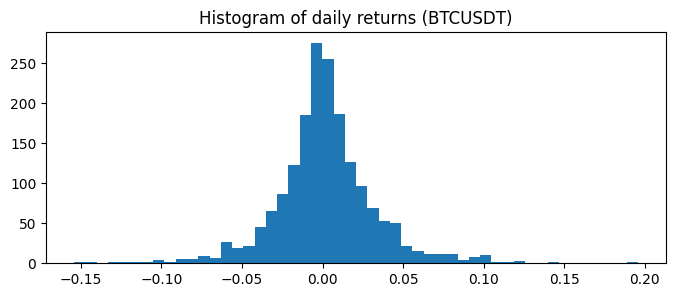

In [17]:
import matplotlib.pyplot as plt

sym = "BTCUSDT"
df = panel_clean[sym].copy()

# Kiểm tra ngày có giá không đổi giữa các cột
same_close = (df["Close"].diff() == 0).sum()
same_open  = (df["Open"].diff() == 0).sum()
print(f"Days with unchanged Close: {same_close}")
print(f"Days with unchanged Open : {same_open}")

# Trực quan return
ret = df["Close"].pct_change()
plt.figure(figsize=(8,3))
plt.hist(ret.dropna(), bins=50)
plt.title(f"Histogram of daily returns ({sym})")
plt.show()


In [18]:
import requests, pandas as pd

url = "https://fapi.binance.com/fapi/v1/klines"
params = {"symbol": "BTCUSDT", "interval": "1d", "startTime": 1602979200000, "endTime": 1603152000000}
r = requests.get(url, params=params)
r.json()[:2]


[[1602979200000,
  '11356.25',
  '11529.93',
  '11342.54',
  '11501.10',
  '92472.191',
  1603065599999,
  '1056889045.95337',
  444193,
  '50893.731',
  '581765716.60191',
  '0'],
 [1603065600000,
  '11501.50',
  '11830.00',
  '11404.01',
  '11745.00',
  '230161.648',
  1603151999999,
  '2677138464.51185',
  770332,
  '121302.088',
  '1410835904.42171',
  '0']]

In [19]:
# === Cell 5c — Outlier & Gap Detector ===
import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Load bản clean
panel = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
symbols = sorted({c[0] for c in panel.columns})

# --- 1️⃣ Kiểm tra missing date / gap ---
date_diff = panel.index.to_series().diff().dt.days
gap_days = date_diff[date_diff > 1]
if not gap_days.empty:
    print("⚠️ Phát hiện ngày bị nhảy > 1:", gap_days.head())
else:
    print("✅ Không có gap thời gian (liên tục 1D).")

# --- 2️⃣ Kiểm tra outlier return ---
def detect_outlier_returns(df):
    r = df["Close"].pct_change()
    return (r.abs() > 0.5).sum(), r

outlier_info = {}
for sym in symbols:
    count, r = detect_outlier_returns(panel[sym])
    outlier_info[sym] = count
    if count > 0:
        print(f"⚠️ {sym} có {count} ngày biến động > ±50%:")
        print(r[r.abs() > 0.5])

# --- 3️⃣ Heatmap volatility toàn bộ ---
close = panel.xs("Close", axis=1, level=1)
rets = close.pct_change()
vol = rets.rolling(20).std() * np.sqrt(365)

fig = px.imshow(
    vol.T,
    title="Volatility 20D (annualized, sqrt(365)) — Outlier visual check",
    color_continuous_scale="RdBu",
    aspect="auto",
)
fig.update_layout(height=400)
fig.show()

# --- 4️⃣ Plot outlier cụ thể BTC/ETH ---
for sym in ["BTCUSDT", "ETHUSDT"]:
    if sym not in rets.columns: continue
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=rets.index, y=rets[sym], mode="lines", name=f"{sym} returns"))
    mask_outlier = rets[sym].abs() > 0.5
    fig.add_trace(go.Scatter(x=rets.index[mask_outlier], y=rets[sym][mask_outlier],
                             mode="markers", name="Outlier ±50%", marker=dict(color="red", size=8)))
    fig.update_layout(title=f"Daily returns (±50% outlier) — {sym}", yaxis_title="Return")
    fig.show()


✅ Không có gap thời gian (liên tục 1D).
⚠️ BNBUSDT có 1 ngày biến động > ±50%:
2021-02-19    0.708493
Name: Close, dtype: float64
⚠️ DOGEUSDT có 3 ngày biến động > ±50%:
2021-01-02    0.855986
2021-01-28    3.898058
2021-04-16    1.011858
Name: Close, dtype: float64
⚠️ SOLUSDT có 2 ngày biến động > ±50%:
2022-11-09   -0.508816
2022-11-10    0.505556
Name: Close, dtype: float64
⚠️ TRXUSDT có 1 ngày biến động > ±50%:
2024-12-03    0.958213
Name: Close, dtype: float64
⚠️ XRPUSDT có 2 ngày biến động > ±50%:
2021-01-30    0.569008
2023-07-13    0.732314
Name: Close, dtype: float64


In [20]:
# === Cell 5d — Consistency & Intraday Range Check ===
import numpy as np
import pandas as pd
import plotly.express as px

# Load bản clean
panel = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
symbols = sorted({c[0] for c in panel.columns})

violations = []

for sym in symbols:
    df = panel[sym].copy()
    # Kiểm tra consistency
    bad_high = (df["High"] < df[["Open", "Close"]].max(axis=1))
    bad_low  = (df["Low"]  > df[["Open", "Close"]].min(axis=1))
    bad_any  = bad_high | bad_low
    n_bad = bad_any.sum()
    if n_bad > 0:
        violations.append((sym, n_bad))
        print(f"⚠️ {sym} có {n_bad} ngày vi phạm High/Low logic.")
    else:
        print(f"✅ {sym} đạt consistency check (High/Low hợp lý).")

# Tổng hợp kết quả
if violations:
    print("\nTổng hợp lỗi logic:")
    for sym, n_bad in violations:
        print(f" - {sym}: {n_bad} dòng sai")
else:
    print("\n🎯 Tất cả symbol đạt consistency logic.")

# --- Kiểm tra intraday range ratio ---
ratios = {}
for sym in symbols:
    df = panel[sym]
    ratio = (df["High"] - df["Low"]) / df["Close"]
    ratios[sym] = ratio

ratios_df = pd.DataFrame(ratios)

# Thống kê nhanh
desc = ratios_df.describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T
print("\n=== Intraday Range Stats (High–Low)/Close ===")
print(desc[["mean", "50%", "95%", "99%", "max"]].round(3))

# --- Biểu đồ phân phối log-scale ---
fig = px.box(
    ratios_df.melt(var_name="symbol", value_name="intraday_range"),
    x="symbol", y="intraday_range",
    title="Intraday Range Ratio (High–Low)/Close",
    log_y=True,
    color="symbol"
)
fig.update_layout(height=500)
fig.show()


✅ BNBUSDT đạt consistency check (High/Low hợp lý).
✅ BTCUSDT đạt consistency check (High/Low hợp lý).
✅ DOGEUSDT đạt consistency check (High/Low hợp lý).
✅ ETHUSDT đạt consistency check (High/Low hợp lý).
✅ SOLUSDT đạt consistency check (High/Low hợp lý).
✅ TRXUSDT đạt consistency check (High/Low hợp lý).
✅ XRPUSDT đạt consistency check (High/Low hợp lý).

🎯 Tất cả symbol đạt consistency logic.

=== Intraday Range Stats (High–Low)/Close ===
           mean    50%    95%    99%    max
BNBUSDT   0.057  0.044  0.141  0.255  0.797
BTCUSDT   0.047  0.039  0.107  0.183  0.407
DOGEUSDT  0.089  0.066  0.227  0.436  1.247
ETHUSDT   0.061  0.050  0.138  0.220  0.837
SOLUSDT   0.092  0.076  0.198  0.323  1.231
TRXUSDT   0.051  0.035  0.145  0.255  0.902
XRPUSDT   0.076  0.056  0.202  0.350  1.071


In [22]:
# === Cell 6a — Momentum & Trend Features ===
import pandas as pd, numpy as np
import ta  # technical analysis library
import plotly.graph_objects as go

# Load close prices
close = pd.read_parquet(PROCESSED / "um_close_only_1d_aligned.CLEAN.parquet")
symbols = close.columns.tolist()
print(f"Symbols: {symbols}")

# Khởi tạo container
features = {}

for sym in symbols:
    s = close[sym]

    df = pd.DataFrame(index=s.index)
    df["close"] = s

    # 1️⃣ Daily Return
    df["ret_1"] = s.pct_change()

    # 2️⃣ Momentum 20d & 60d
    df["mom_20"] = s / s.shift(20) - 1
    df["mom_60"] = s / s.shift(60) - 1

    # 3️⃣ Mean return 7d
    df["ret_mean_7"] = df["ret_1"].rolling(7).mean()

    # 4️⃣ SMA60 Filter
    sma60 = s.rolling(60).mean()
    df["sma60_filter"] = (s - sma60) / sma60   # >0 ⇒ uptrend

    # 5️⃣ RSI14
    df["rsi14"] = ta.momentum.RSIIndicator(close=s, window=14).rsi()

    features[sym] = df

# Gộp MultiIndex
panel_featA = pd.concat(features, axis=1)
panel_featA.columns = pd.MultiIndex.from_tuples(panel_featA.columns)
panel_featA = panel_featA.sort_index(axis=1)

print("✅ Done: Momentum & Trend Features")
panel_featA.tail(3)


Symbols: ['BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']
✅ Done: Momentum & Trend Features


BNBUSDT                                                      \
              close    mom_20    mom_60     ret_1 ret_mean_7      rsi14   
2025-10-14  1208.03  0.185726  0.458973 -0.066228  -0.007980  56.700474   
2025-10-15  1163.09  0.228846  0.386331 -0.037201  -0.013460  53.066660   
2025-10-16  1144.65  0.190756  0.337270 -0.015854  -0.010185  51.605215   

                          BTCUSDT                      ...    TRXUSDT  \
           sma60_filter     close    mom_20    mom_60  ... ret_mean_7   
2025-10-14     0.234554  112983.8 -0.002386 -0.036625  ...  -0.008883   
2025-10-15     0.182102  110699.0  0.016198 -0.056513  ...  -0.009573   
2025-10-16     0.157699  108129.4 -0.013314 -0.078603  ...  -0.008884   

                                   XRPUSDT                                \
                rsi14 sma60_filter   close    mom_20    mom_60     ret_1   
2025-10-14  36.782460    -0.070217  2.5020 -0.144498 -0.186685 -0.039244   
2025-10-15  39.205805    -0.061355  2.4097 -0.121189 -0.223654 -0.036890   
2025-10-16  37.277685    -0.069121  2.3268 -0.163713 -0.245917 -0.034403   

                                               
           ret_mean_7      rsi14 sma60_filter  
2025-10-14  -0.016229  37.107570    -0.135731  
2025-10-15  -0.022887  34.230076    -0.164275  
2025-10-16  -0.023956  31.841787    -0.189471  

[3 rows x 49 columns]

In [24]:
# === Cell 6a-vis (Full) — visualize all 6 trend features ===
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Chọn coin để xem chi tiết
sym_list = ["BTCUSDT", "ETHUSDT"]

for sym in sym_list:
    df = features[sym].copy()

    # 6 hàng: Price, Return, Mom20, Mom60, Mean7, RSI14
    fig = make_subplots(
        rows=6, cols=1, shared_xaxes=True, vertical_spacing=0.03,
        subplot_titles=(
            f"{sym} Close + SMA60",
            "Daily Return (r₁)",
            "Momentum 20d",
            "Momentum 60d",
            "Return Mean 7d",
            "RSI14"
        )
    )

    # 1️⃣ Close + SMA60
    fig.add_trace(go.Scatter(x=df.index, y=df["close"], name="Close", line=dict(color="black")), row=1, col=1)
    fig.add_trace(go.Scatter(x=df.index, y=df["close"].rolling(60).mean(), name="SMA60", line=dict(color="blue")), row=1, col=1)

    # 2️⃣ Daily Return
    fig.add_trace(go.Scatter(x=df.index, y=df["ret_1"], name="ret_1", line=dict(color="green")), row=2, col=1)

    # 3️⃣ Momentum 20d
    fig.add_trace(go.Scatter(x=df.index, y=df["mom_20"], name="mom_20", line=dict(color="orange")), row=3, col=1)

    # 4️⃣ Momentum 60d
    fig.add_trace(go.Scatter(x=df.index, y=df["mom_60"], name="mom_60", line=dict(color="red")), row=4, col=1)

    # 5️⃣ Mean Return 7d
    fig.add_trace(go.Scatter(x=df.index, y=df["ret_mean_7"], name="ret_mean_7", line=dict(color="purple")), row=5, col=1)

    # 6️⃣ RSI14
    fig.add_trace(go.Scatter(x=df.index, y=df["rsi14"], name="RSI14", line=dict(color="brown")), row=6, col=1)
    fig.add_hline(y=70, line_dash="dot", line_color="gray", row=6, col=1)
    fig.add_hline(y=30, line_dash="dot", line_color="gray", row=6, col=1)

    fig.update_layout(
        height=1200, width=1000,
        title_text=f"{sym} — Momentum & Trend Feature Set (6 features)",
        showlegend=False,
        template="plotly_white"
    )

    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Return", row=2, col=1)
    fig.update_yaxes(title_text="Momentum", row=3, col=1)
    fig.update_yaxes(title_text="Momentum", row=4, col=1)
    fig.update_yaxes(title_text="Return mean", row=5, col=1)
    fig.update_yaxes(title_text="RSI", row=6, col=1, range=[0, 100])

    fig.show()


In [25]:
# === Cell 6b — Volatility & Risk Features ===
import pandas as pd, numpy as np
import ta
import plotly.express as px
import plotly.graph_objects as go

# Load OHLCV panel (MultiIndex)
panel = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
symbols = sorted({c[0] for c in panel.columns})

feat_vol = {}

for sym in symbols:
    df = panel[sym].copy()

    out = pd.DataFrame(index=df.index)
    out["close"] = df["Close"]

    # 6️⃣ Rolling Volatility 20d (annualized)
    rets = df["Close"].pct_change()
    out["vol20"] = rets.rolling(20).std() * np.sqrt(365)

    # 7️⃣ ATR14
    atr = ta.volatility.AverageTrueRange(
        high=df["High"], low=df["Low"], close=df["Close"], window=14
    ).average_true_range()
    out["atr14"] = atr

    # 8️⃣ Volatility Ratio σ10 / σ60
    vol10 = rets.rolling(10).std()
    vol60 = rets.rolling(60).std()
    out["vol_ratio_10_60"] = vol10 / vol60

    # 9️⃣ Max Drawdown (local 60d)
    roll_max = df["Close"].rolling(60, min_periods=1).max()
    drawdown = df["Close"] / roll_max - 1
    out["mdd60"] = drawdown

    feat_vol[sym] = out

# Gộp MultiIndex
panel_featB = pd.concat(feat_vol, axis=1)
panel_featB.columns = pd.MultiIndex.from_tuples(panel_featB.columns)
panel_featB = panel_featB.sort_index(axis=1)

print("✅ Done: Volatility & Risk Features")
panel_featB.tail(3)


✅ Done: Volatility & Risk Features


BNBUSDT                                               \
                 atr14    close     mdd60     vol20 vol_ratio_10_60   
2025-10-14  106.057268  1208.03 -0.075610  1.158192        1.847210   
2025-10-15  103.807463  1163.09 -0.109998  1.121045        1.859558   
2025-10-16  101.661930  1144.65 -0.124109  1.127128        1.817343   

                BTCUSDT                                                ...  \
                  atr14     close     mdd60     vol20 vol_ratio_10_60  ...   
2025-10-14  4329.270669  112983.8 -0.093435  0.506250        1.581729  ...   
2025-10-15  4268.551335  110699.0 -0.111768  0.485532        1.549927  ...   
2025-10-16  4292.940525  108129.4 -0.132386  0.495815        1.499526  ...   

             TRXUSDT                                                XRPUSDT  \
               atr14    close     mdd60     vol20 vol_ratio_10_60     atr14   
2025-10-14  0.010003  0.31655 -0.136643  0.347808        1.147840  0.225475   
2025-10-15  0.010022  0.31912 -0.129633  0.343942        1.164978  0.221726   
2025-10-16  0.010063  0.31590 -0.138415  0.331772        1.110074  0.218953   

                                                        
             close     mdd60     vol20 vol_ratio_10_60  
2025-10-14  2.5020 -0.197588  0.876910        1.680885  
2025-10-15  2.4097 -0.227190  0.852165        1.671994  
2025-10-16  2.3268 -0.253776  0.855693        1.645593  

[3 rows x 35 columns]

In [26]:
# === Cell 6b-vis — Visualize Volatility & Drawdown ===
import plotly.graph_objects as go
from plotly.subplots import make_subplots

for sym in ["BTCUSDT", "ETHUSDT"]:
    df = feat_vol[sym]

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.04,
        subplot_titles=("Rolling Volatility 20D", "ATR14", "Max Drawdown 60D")
    )

    # Volatility
    fig.add_trace(go.Scatter(x=df.index, y=df["vol20"], name="Vol20", line=dict(color="blue")), row=1, col=1)

    # ATR14
    fig.add_trace(go.Scatter(x=df.index, y=df["atr14"], name="ATR14", line=dict(color="orange")), row=2, col=1)

    # Max Drawdown
    fig.add_trace(go.Scatter(x=df.index, y=df["mdd60"], name="MDD60", line=dict(color="red")), row=3, col=1)
    fig.add_hline(y=0, line_color="black", line_dash="dot", row=3, col=1)
    fig.add_hline(y=-0.3, line_color="gray", line_dash="dot", row=3, col=1)

    fig.update_layout(
        title=f"{sym} — Volatility & Risk Features",
        height=900, width=1000, template="plotly_white",
        showlegend=False
    )
    fig.show()


In [27]:
# === Cell 6c — Volume & Market Confirmation Features ===
import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Load panel OHLCV
panel = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
symbols = sorted({c[0] for c in panel.columns})

feat_volm = {}

for sym in symbols:
    df = panel[sym].copy()
    out = pd.DataFrame(index=df.index)
    out["close"] = df["Close"]
    out["volume"] = df["volume"]

    # 10️⃣ Volume Ratio 20d
    out["vol_ratio_20"] = df["volume"] / df["volume"].rolling(20).mean()

    # 11️⃣ OBV (On-Balance Volume) & OBV Change 20d
    direction = np.sign(df["Close"].diff().fillna(0))
    obv = (direction * df["volume"]).cumsum()
    out["obv_change_20"] = obv.pct_change(20)

    # 12️⃣ Price–Volume Correlation 30d
    delta_p = df["Close"].pct_change()
    delta_v = df["volume"].pct_change()
    out["price_vol_corr_30"] = (
        delta_p.rolling(30).corr(delta_v)
    )

    feat_volm[sym] = out

# Gộp MultiIndex
panel_featC = pd.concat(feat_volm, axis=1)
panel_featC.columns = pd.MultiIndex.from_tuples(panel_featC.columns)
panel_featC = panel_featC.sort_index(axis=1)

print("✅ Done: Volume & Market Confirmation Features")
panel_featC.tail(3)


✅ Done: Volume & Market Confirmation Features


BNBUSDT                                                           \
              close obv_change_20 price_vol_corr_30 vol_ratio_20      volume   
2025-10-14  1208.03      0.031364          0.343054     1.803085  4103220.59   
2025-10-15  1163.09      0.031721          0.368930     0.802357  1825758.36   
2025-10-16  1144.65      0.013325          0.357257     0.850412  1969968.75   

             BTCUSDT                                                           \
               close obv_change_20 price_vol_corr_30 vol_ratio_20      volume   
2025-10-14  112983.8     -0.080141         -0.255679     1.615349  259244.496   
2025-10-15  110699.0     -0.091218         -0.231664     0.833273  131777.090   
2025-10-16  108129.4      0.013308         -0.229797     1.193194  193544.785   

            ...  TRXUSDT                                               \
            ...    close obv_change_20 price_vol_corr_30 vol_ratio_20   
2025-10-14  ...  0.31655     -0.011289         -0.406044     1.838801   
2025-10-15  ...  0.31912     -0.006602         -0.407894     1.379374   
2025-10-16  ...  0.31590     -0.010986         -0.408643     1.420372   

                        XRPUSDT                                               \
                 volume   close obv_change_20 price_vol_corr_30 vol_ratio_20   
2025-10-14  610515982.0  2.5020      0.011959         -0.622491     1.877268   
2025-10-15  461373741.0  2.4097      0.013411         -0.585581     0.887367   
2025-10-16  486172808.0  2.3268      0.004546         -0.578125     1.113610   

                          
                  volume  
2025-10-14  1.454943e+09  
2025-10-15  6.770399e+08  
2025-10-16  8.598702e+08  

[3 rows x 35 columns]

In [28]:
# === Cell 6c-vis — Visualize Volume & Confirmation ===
from plotly.subplots import make_subplots

for sym in ["BTCUSDT", "ETHUSDT"]:
    df = feat_volm[sym]

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.04,
        subplot_titles=("Volume Ratio 20D", "OBV Change 20D", "Price–Volume Corr 30D")
    )

    # Volume Ratio 20D
    fig.add_trace(go.Scatter(x=df.index, y=df["vol_ratio_20"], name="vol_ratio_20",
                             line=dict(color="blue")), row=1, col=1)
    fig.add_hline(y=1.0, line_dash="dot", line_color="gray", row=1, col=1)

    # OBV Change 20D
    fig.add_trace(go.Scatter(x=df.index, y=df["obv_change_20"], name="obv_change_20",
                             line=dict(color="green")), row=2, col=1)

    # Price–Volume Corr 30D
    fig.add_trace(go.Scatter(x=df.index, y=df["price_vol_corr_30"], name="price_vol_corr_30",
                             line=dict(color="orange")), row=3, col=1)
    fig.add_hline(y=0, line_dash="dot", line_color="black", row=3, col=1)

    fig.update_layout(
        title=f"{sym} — Volume & Market Confirmation Features",
        height=900, width=1000, template="plotly_white",
        showlegend=False
    )
    fig.show()


In [29]:
# === Cell 6d — Relative Strength & Cross-Asset Features ===
import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Load Close-only
close = pd.read_parquet(PROCESSED / "um_close_only_1d_aligned.CLEAN.parquet")
symbols = close.columns.tolist()
assert "BTCUSDT" in symbols, "Cần có BTCUSDT để làm benchmark"

feat_rel = {}

# 13️⃣ Relative Momentum vs BTC (RelMom20)
mom20 = close.pct_change(20)
btc_mom = mom20["BTCUSDT"]
rel_mom20 = mom20.subtract(btc_mom, axis=0)  # coin - BTC

# 14️⃣ Beta (30d) vs BTC
rets = close.pct_change()
cov_with_btc = rets.rolling(30).cov(rets["BTCUSDT"])
var_btc = rets["BTCUSDT"].rolling(30).var()
beta30 = cov_with_btc.div(var_btc, axis=0)

# 15️⃣ Market Breadth Strength (tỷ lệ coin > SMA60)
sma60 = close.rolling(60).mean()
breadth = (close > sma60).sum(axis=1) / len(symbols)

# Gom kết quả
for sym in symbols:
    df = pd.DataFrame(index=close.index)
    df["rel_mom20"] = rel_mom20[sym]
    df["beta30"] = beta30[sym]
    df["breadth_strength"] = breadth
    feat_rel[sym] = df

panel_featD = pd.concat(feat_rel, axis=1)
panel_featD.columns = pd.MultiIndex.from_tuples(panel_featD.columns)
panel_featD = panel_featD.sort_index(axis=1)

print("✅ Done: Relative Strength & Cross-Asset Features")
panel_featD.tail(3)


✅ Done: Relative Strength & Cross-Asset Features


BNBUSDT                            BTCUSDT                   \
              beta30 breadth_strength rel_mom20  beta30 breadth_strength   
2025-10-14  1.621662         0.142857  0.188112     1.0         0.142857   
2025-10-15  1.643906         0.142857  0.212648     1.0         0.142857   
2025-10-16  1.620583         0.142857  0.204070     1.0         0.142857   

                      DOGEUSDT                              ETHUSDT  ...  \
           rel_mom20    beta30 breadth_strength rel_mom20    beta30  ...   
2025-10-14       0.0  2.460965         0.142857 -0.149957  1.715671  ...   
2025-10-15       0.0  2.442480         0.142857 -0.136031  1.713881  ...   
2025-10-16       0.0  2.428827         0.142857 -0.175821  1.713193  ...   

                       SOLUSDT                              TRXUSDT  \
           rel_mom20    beta30 breadth_strength rel_mom20    beta30   
2025-10-14 -0.004230  2.092872         0.142857 -0.040698  0.622036   
2025-10-15  0.012387  2.091412         0.142857 -0.010331  0.592611   
2025-10-16 -0.020965  2.096660         0.142857 -0.085461  0.597834   

                                        XRPUSDT                             
           breadth_strength rel_mom20    beta30 breadth_strength rel_mom20  
2025-10-14         0.142857 -0.060965  1.596195         0.142857 -0.142113  
2025-10-15         0.142857 -0.054356  1.596673         0.142857 -0.137387  
2025-10-16         0.142857 -0.052761  1.588228         0.142857 -0.150399  

[3 rows x 21 columns]

In [30]:
# === Cell 6d-vis — Visualize Relative & Breadth ===
from plotly.subplots import make_subplots

for sym in ["ETHUSDT", "BNBUSDT", "SOLUSDT"]:
    df = feat_rel[sym]

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.04,
        subplot_titles=("Relative Momentum 20D vs BTC",
                        "Beta 30D vs BTC",
                        "Market Breadth Strength (all coins)")
    )

    # Relative Momentum
    fig.add_trace(go.Scatter(x=df.index, y=df["rel_mom20"],
                             name="RelMom20", line=dict(color="green")), row=1, col=1)
    fig.add_hline(y=0, line_dash="dot", line_color="gray", row=1, col=1)

    # Beta30
    fig.add_trace(go.Scatter(x=df.index, y=df["beta30"],
                             name="Beta30", line=dict(color="orange")), row=2, col=1)
    fig.add_hline(y=1, line_dash="dot", line_color="gray", row=2, col=1)

    # Breadth
    fig.add_trace(go.Scatter(x=df.index, y=df["breadth_strength"],
                             name="Breadth", line=dict(color="blue")), row=3, col=1)
    fig.add_hline(y=0.5, line_dash="dot", line_color="gray", row=3, col=1)

    fig.update_layout(
        title=f"{sym} — Relative Strength & Market Breadth",
        height=900, width=1000, template="plotly_white",
        showlegend=False
    )
    fig.show()


In [34]:
# === Cell 7 (fixed) — Build unified 15-feature panel (no duplicates) + correlation ===
import pandas as pd
import numpy as np
import plotly.express as px

# 0) Check 4 panel features are present
required = ["panel_featA", "panel_featB", "panel_featC", "panel_featD"]
missing = [v for v in required if v not in globals()]
assert not missing, f"Thiếu biến {missing}. Hãy chạy Cell 6a–6d trước."

# 1) Chuẩn hóa tên cột mỗi nhóm (bỏ close/volume), chỉ giữ feature cần
def pick_cols(df, wanted):
    cols = []
    for sym in sorted({c[0] for c in df.columns}):
        for name in wanted:
            key = (sym, name)
            if key in df.columns:
                cols.append(key)
    return df.loc[:, cols]

# A: momentum & trend (6)
A_keep = ["ret_1","mom_20","mom_60","ret_mean_7","sma60_filter","rsi14"]
A = pick_cols(panel_featA, A_keep)

# B: volatility & risk (4)
B_keep = ["vol20","atr14","vol_ratio_10_60","mdd60"]
B = pick_cols(panel_featB, B_keep)

# C: volume & confirmation (3)
C_keep = ["vol_ratio_20","obv_change_20","price_vol_corr_30"]
C = pick_cols(panel_featC, C_keep)

# D: relative & cross-asset (3)  -> lưu ý breadth_strength lặp theo coin (cùng giá trị)
D_keep = ["rel_mom20","beta30","breadth_strength"]
D = pick_cols(panel_featD, D_keep)

# 2) Gộp lại theo thứ tự A+B+C+D (15 feature)
panel_all = pd.concat([A, B, C, D], axis=1).sort_index(axis=1)

# 3) Đảm bảo không có cột trùng tên nữa
dupes = panel_all.columns.duplicated()
if dupes.any():
    # Nếu vẫn trùng (hiếm), chỉ giữ lần xuất hiện đầu
    panel_all = panel_all.loc[:, ~dupes]

# 4) Lưu ra parquet
out_path = PROCESSED / "panel_all_features_15.parquet"
panel_all.to_parquet(out_path)
print("✅ Saved unified 15-feature panel:", out_path)

# 5) QC nhanh cho 1 symbol (BTCUSDT)
sym = "BTCUSDT"
assert sym in panel_all.columns.get_level_values(0), f"{sym} không có trong panel_all."
btc = panel_all[sym].copy()

# Đổi tên cột cho gọn (hiển thị)
rename_map = {
    "ret_1": "r1",
    "mom_20": "momentum_20",
    "mom_60": "momentum_60",
    "ret_mean_7": "ret_mean_7",
    "sma60_filter": "sma60_filter",
    "rsi14": "rsi_14",
    "vol20": "volatility_20",
    "atr14": "atr_14",
    "vol_ratio_10_60": "vol_ratio_10_60",
    "mdd60": "maxdd_60",
    "vol_ratio_20": "vol_ratio_20",
    "obv_change_20": "obv_change_20",
    "price_vol_corr_30": "price_vol_corr_30",
    "rel_mom20": "rel_mom20",
    "beta30": "beta_30",
    "breadth_strength": "breadth_strength",
}
btc = btc.rename(columns={k:v for k,v in rename_map.items() if k in btc.columns})

print("\n=== BTCUSDT — Summary of 15 features (non-NaN) ===")
desc = btc.dropna().describe(percentiles=[0.01,0.05,0.95,0.99]).T
display(desc[["mean","std","min","1%","5%","95%","99%","max"]].round(4))

# 6) Correlation heatmap (BTCUSDT)
corr = btc.corr().replace([np.inf, -np.inf], np.nan).fillna(0)
fig = px.imshow(
    corr, title="Correlation Matrix — BTCUSDT (15 features)",
    color_continuous_scale="RdBu", zmin=-1, zmax=1,
    height=700, width=900, aspect="auto"
)
fig.show()


✅ Saved unified 15-feature panel: C:\Users\Admin\Desktop\phongvan\data\crypto_data\processed\panel_all_features_15.parquet

=== BTCUSDT — Summary of 15 features (non-NaN) ===


,mean,std,min,1%,5%,95%,99%,max
atr_14,2278.0806,1132.7947,303.5525,428.9300,664.8685,4189.1693,4886.2616,5365.9857
beta_30,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
breadth_strength,0.5454,0.3717,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
maxdd_60,-0.1183,0.1135,-0.5412,-0.4681,-0.3720,0.0000,0.0000,0.0000
momentum_20,0.0318,0.1548,-0.4062,-0.3174,-0.1791,0.3187,0.5613,0.7153
momentum_60,0.1122,0.3279,-0.5428,-0.4492,-0.3385,0.6754,1.2862,1.6511
obv_change_20,0.0617,1.2834,-12.5488,-1.4351,-0.5068,0.6745,2.5988,31.6457
price_vol_corr_30,-0.0818,0.2899,-0.7690,-0.7256,-0.5773,0.3736,0.6947,0.8084
rel_mom20,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
r1,0.0014,0.0311,-0.1541,-0.0845,-0.0475,0.0511,0.0971,0.1957


In [41]:
# === Cell 8-SIMPLE — Rule-based Futures (no leverage, no SL/TP, no rebalance) ===
import numpy as np, pandas as pd
from dataclasses import dataclass
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ---------------- Hyper-parameters (chỉnh ở đây) ----------------
@dataclass
class ParamsS:
    START: str = "2020-10-18"
    END:   str = "2025-10-16"
    SYMBOLS: list | None = None

    # ---- Rule core (>=7 features) ----
    RSI_MIN_LONG: float = 55.0
    RSI_MAX_SHORT: float = 45.0
    MOM20_MIN: float = 0.0
    MOM60_MIN: float = 0.0
    MOM20_MAX_SHORT: float = 0.0
    MOM60_MAX_SHORT: float = 0.0
    SMA60_FILTER_ON: bool = True
    VOLR20_MIN: float = 1.0
    PVCORR_MIN: float = 0.0
    RELMOM_MIN: float = 0.0
    BETA_MAX: float = 2.5
    BREADTH_LONG_MIN: float = 0.5
    BREADTH_SHORT_MAX: float = 0.4
    ALLOW_SHORT: bool = True

    # ---- Portfolio selection ----
    MAX_COINS: int = 3                # tối đa số mã đang giữ
    WEIGHTING: str = "equal"          # "equal" | "inv_vol"
    MAX_GROSS_EXPOSURE: float = 1.0   # tổng |weight| trong ngày

    # ---- Fees (không đòn bẩy, không SL/TP) ----
    FEE_IN: float = 0.0005            # 0.05% vào
    FEE_OUT: float = 0.0005           # 0.05% ra
    SLIPPAGE: float = 0.0002          # 0.02% mỗi lần khớp
    # phí áp theo trọng số notional trong ngày có thay đổi trạng thái

    INITIAL_CAPITAL: float = 1_000_000.0

PS = ParamsS()

# ---------------- Load dữ liệu ----------------
panel = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")      # OHLCV MultiIndex
feat  = pd.read_parquet(PROCESSED / "panel_all_features_15.parquet")     # 15 features MultiIndex

all_syms = sorted({c[0] for c in panel.columns})
symbols = all_syms if PS.SYMBOLS is None else [s for s in PS.SYMBOLS if s in all_syms]

idx = pd.date_range(PS.START, PS.END, freq="D")
close = pd.concat({s: panel[s]["Close"] for s in symbols}, axis=1).reindex(idx)
rets  = close.pct_change()  # daily simple returns
vol20 = pd.concat({s: feat[s]["vol20"] for s in symbols}, axis=1).reindex(idx)

# breadth lấy từ 1 symbol (giá trị giống nhau cho mọi symbol)
breadth = feat[symbols[0]]["breadth_strength"].reindex(idx)

# ---------------- Tạo tín hiệu (không lookahead) ----------------
def signal_for_sym(sym):
    f = feat[sym].reindex(idx)
    sig_long = (
        (f["rsi14"] >= PS.RSI_MIN_LONG) &
        (f["mom_20"] > PS.MOM20_MIN) &
        (f["mom_60"] > PS.MOM60_MIN) &
        ((~PS.SMA60_FILTER_ON) | (f["sma60_filter"] > 0)) &
        (f["vol_ratio_20"] >= PS.VOLR20_MIN) &
        (f["price_vol_corr_30"] >= PS.PVCORR_MIN) &
        (f["rel_mom20"] >= PS.RELMOM_MIN) &
        (f["beta30"].between(0, PS.BETA_MAX, inclusive="both")) &
        (breadth >= PS.BREADTH_LONG_MIN)
    )
    sig_short = pd.Series(False, index=idx)
    if PS.ALLOW_SHORT:
        sig_short = (
            (f["rsi14"] <= PS.RSI_MAX_SHORT) &
            (f["mom_20"] < PS.MOM20_MAX_SHORT) &
            (f["mom_60"] < PS.MOM60_MAX_SHORT) &
            ((~PS.SMA60_FILTER_ON) | (f["sma60_filter"] < 0)) &
            (breadth <= PS.BREADTH_SHORT_MAX)
        )
    sig = pd.Series(0, index=idx, dtype=int)
    sig = sig.mask(sig_long,  +1)
    sig = sig.mask(sig_short, -1)
    return sig.shift(1).fillna(0)  # dùng ở t dựa trên feature t-1

signals = pd.concat({s: signal_for_sym(s) for s in symbols}, axis=1)

# ---------------- Chọn vị thế mỗi ngày (max N coin) ----------------
mom60 = pd.concat({s: feat[s]["mom_60"] for s in symbols}, axis=1).reindex(idx).shift(1)

def pick_positions(d):
    longs  = [s for s in symbols if signals.loc[d, s] ==  1]
    shorts = [s for s in symbols if signals.loc[d, s] == -1]
    longs  = sorted(longs,  key=lambda s: mom60.loc[d, s], reverse=True)
    shorts = sorted(shorts, key=lambda s: mom60.loc[d, s])
    picks = longs[:PS.MAX_COINS]
    if len(picks) < PS.MAX_COINS and PS.ALLOW_SHORT:
        picks += shorts[: PS.MAX_COINS - len(picks)]
    return picks

def compute_weights(d, picks):
    if not picks:
        return {}
    if PS.WEIGHTING == "equal":
        w = PS.MAX_GROSS_EXPOSURE / max(1, len(picks))
        return {s: np.sign(signals.loc[d, s]) * w for s in picks}
    else:
        vv = np.array([max(1e-8, float(vol20.loc[d, s])) for s in picks])
        inv = (1.0 / vv); inv = inv / inv.sum()
        gross = PS.MAX_GROSS_EXPOSURE
        return {s: np.sign(signals.loc[d, s]) * gross * w for s, w in zip(picks, inv)}

# ---------------- Backtest close-to-close, phí khi đổi trạng thái ----------------
# state: position weights per symbol (side * w), changes only when picks differ
w_prev = pd.Series(0.0, index=symbols)
equity = [PS.INITIAL_CAPITAL]
ret_series = []

fee_rate_in  = PS.FEE_IN  + PS.SLIPPAGE
fee_rate_out = PS.FEE_OUT + PS.SLIPPAGE

for i, d in enumerate(idx):
    # 1) xác định target weights hôm nay
    picks = pick_positions(d)
    w_today = pd.Series(0.0, index=symbols)
    w_map = compute_weights(d, picks)
    for s in w_map: w_today[s] = w_map[s]

    # 2) phí giao dịch nếu có thay đổi trạng thái
    # change per symbol: open/close/flip
    change = (w_today - w_prev)
    # phí mở mới (prev==0 -> now!=0) : fee_in
    open_mask  = (w_prev == 0) & (w_today != 0)
    close_mask = (w_prev != 0) & (w_today == 0)
    flip_mask  = (w_prev * w_today < 0)   # đảo chiều

    fee_frac = (
        (open_mask.astype(float)  * abs(w_today) * fee_rate_in) +
        (close_mask.astype(float) * abs(w_prev)  * fee_rate_out) +
        (flip_mask.astype(float)  * (abs(w_prev)*fee_rate_out + abs(w_today)*fee_rate_in))
    ).sum()

    # 3) PnL close-to-close: r_t * weight_t  (weight áp trong cả ngày t)
    day_ret = (rets.loc[d] * w_today).sum()  # không đòn bẩy

    # 4) update equity
    prev_eq = equity[-1]
    eq = prev_eq * (1 + day_ret - fee_frac)
    equity.append(eq)
    ret_series.append(day_ret - fee_frac)

    # 5) giữ state
    w_prev = w_today

equity = pd.Series(equity[1:], index=idx, name="equity")
daily_ret = pd.Series(ret_series, index=idx, name="ret")

# ---------------- Metrics ----------------
def perf_stats(eq, r):
    eq = eq.dropna(); r = r.dropna()
    days = (eq.index[-1] - eq.index[0]).days + 1
    cagr = (eq.iloc[-1] / eq.iloc[0])**(365.0 / max(1, days)) - 1
    vol  = r.std() * np.sqrt(365)
    sharpe = 0 if r.std()==0 else r.mean()/r.std()*np.sqrt(365)
    roll_max = eq.cummax(); mdd = (eq/roll_max - 1).min()
    hit = (r > 0).mean()
    return dict(start=eq.index[0], end=eq.index[-1], days=days,
                cagr=cagr, vol=vol, sharpe=sharpe, mdd=mdd, hit_ratio=hit)

stats = perf_stats(equity, daily_ret)

print(f"Start: {stats['start'].date()}  |  End: {stats['end'].date()}  |  Days: {stats['days']}")
print(f"Annual Return (CAGR): {stats['cagr']*100:,.2f}%")
print(f"Annual Volatility   : {stats['vol']*100:,.2f}%")
print(f"Sharpe (rf=0)       : {stats['sharpe']:.2f}")
print(f"Max Drawdown (MDD)  : {stats['mdd']*100:,.2f}%")
print(f"Hit Ratio (daily>0) : {stats['hit_ratio']*100:,.2f}%")
print(f"Final Equity        : {equity.iloc[-1]:,.0f} (start {PS.INITIAL_CAPITAL:,.0f})")

# ---------------- Plot ----------------
roll_max = equity.cummax()
drawdown = equity/roll_max - 1

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=("Equity Curve (simple)", "Drawdown"))
fig.add_trace(go.Scatter(x=equity.index, y=equity, name="Equity"), row=1, col=1)
fig.add_trace(go.Scatter(x=drawdown.index, y=drawdown, name="Drawdown"), row=2, col=1)
fig.add_hline(y=0, line_dash="dot", line_color="gray", row=2, col=1)
fig.update_layout(height=700, width=1000, template="plotly_white")
fig.show()


Start: 2020-10-18  |  End: 2025-10-16  |  Days: 1825
Annual Return (CAGR): 77.19%
Annual Volatility   : 82.96%
Sharpe (rf=0)       : 1.08
Max Drawdown (MDD)  : -64.68%
Hit Ratio (daily>0) : 29.37%
Final Equity        : 17,464,309 (start 1,000,000)


In [92]:
# === Cell 8 — FIX: Regime + ATR SL/TP (no leverage, safer sizing) ===
import numpy as np, pandas as pd
from dataclasses import dataclass
from plotly.subplots import make_subplots
import plotly.graph_objects as go

@dataclass
class P8:
    START: str = "2020-10-18"
    END:   str = "2025-10-16"
    SYMBOLS: list | None = None

    # Feature rules (>=7)
    RSI_MIN_LONG: float = 55.0
    RSI_MAX_SHORT: float = 35.0
    MOM20_MIN: float = -0.2
    MOM60_MIN: float = -0.2
    MOM20_MAX_SHORT: float = 0.00
    MOM60_MAX_SHORT: float = 0.00
    SMA60_FILTER_ON: bool = True
    VOLR20_MIN: float = 1
    PVCORR_MIN: float = 0.1
    RELMOM_MIN: float = 0.0
    BETA_MAX: float = 2
    ALLOW_SHORT: bool = True

    # Regime
    REGIME_ON_MIN_BREADTH: float = 0.50
    REGIME_OFF_MAX_BREADTH: float = 0.40
    REGIME_BTC_SMA60_ON: bool = True
    REGIME_BTC_RSI_MIN: float = 50.0
    CLOSE_ALL_ON_REGIME_OFF: bool = True

    # Portfolio
    MAX_COINS: int = 2
    WEIGHTING: str = "equal"       # "equal" | "inv_vol"
    MAX_GROSS_EXPOSURE: float = 1.0
    FIXED_FRACTION_PER_TRADE: float = 0.2  # fraction of gross exposure / trade cap

    # Fees (per fill) — charged on notional qty*price
    FEE_IN: float = 0.0005
    FEE_OUT: float = 0.0005
    SLIPPAGE: float = 0.0002

    # ATR stops
    SL_ATR_MULT: float = 2.5
    TP_ATR_MULT: float = 3
    STOP_TP_PRIORITY: str = "stop"   # "stop"|"tp"
    COOLDOWN_AFTER_EXIT: bool = True # không mở lại cùng mã trong ngày đã SL/TP

    # Engine
    INITIAL_CAPITAL: float = 1_000_000.0
    N_TRADES_PREVIEW: int = 15

P = P8()

# -------- Load
panel = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
feat  = pd.read_parquet(PROCESSED / "panel_all_features_15.parquet")

all_syms = sorted({c[0] for c in panel.columns})
symbols = all_syms if P.SYMBOLS is None else [s for s in P.SYMBOLS if s in all_syms]

idx = pd.date_range(P.START, P.END, freq="D")
open_px  = pd.concat({s: panel[s]["Open"]  for s in symbols}, axis=1).reindex(idx)
high_px  = pd.concat({s: panel[s]["High"]  for s in symbols}, axis=1).reindex(idx)
low_px   = pd.concat({s: panel[s]["Low"]   for s in symbols}, axis=1).reindex(idx)
close_px = pd.concat({s: panel[s]["Close"] for s in symbols}, axis=1).reindex(idx)
rets     = close_px.pct_change()
vol20    = pd.concat({s: feat[s]["vol20"]  for s in symbols}, axis=1).reindex(idx)
atr14    = pd.concat({s: feat[s]["atr14"]  for s in symbols}, axis=1).reindex(idx)

# -------- Regime (shift(1))
breadth = feat["BTCUSDT"]["breadth_strength"].reindex(idx).shift(1)
btc_rsi = feat["BTCUSDT"]["rsi14"].reindex(idx).shift(1)
btc_sma = feat["BTCUSDT"]["sma60_filter"].reindex(idx).shift(1)
risk_on  = (breadth >= P.REGIME_ON_MIN_BREADTH)
if P.REGIME_BTC_SMA60_ON: risk_on &= (btc_sma > 0)
risk_on &= (btc_rsi >= P.REGIME_BTC_RSI_MIN)
risk_off = (breadth <= P.REGIME_OFF_MAX_BREADTH) & (btc_sma < 0)

# -------- Signals (shift(1))
def signals_for(sym):
    f = feat[sym].reindex(idx)
    long_cond = (
        (f["rsi14"] >= P.RSI_MIN_LONG) &
        (f["mom_20"] > P.MOM20_MIN) &
        (f["mom_60"] > P.MOM60_MIN) &
        ((~P.SMA60_FILTER_ON) | (f["sma60_filter"] > 0)) &
        (f["vol_ratio_20"] >= P.VOLR20_MIN) &
        (f["price_vol_corr_30"] >= P.PVCORR_MIN) &
        (f["rel_mom20"] >= P.RELMOM_MIN) &
        (f["beta30"].between(0, P.BETA_MAX, inclusive="both")) &
        (risk_on)
    )
    short_cond = pd.Series(False, index=idx)
    if P.ALLOW_SHORT:
        short_cond = (
            (f["rsi14"] <= P.RSI_MAX_SHORT) &
            (f["mom_20"] < P.MOM20_MAX_SHORT) &
            (f["mom_60"] < P.MOM60_MAX_SHORT) &
            ((~P.SMA60_FILTER_ON) | (f["sma60_filter"] < 0)) &
            (risk_off)
        )
    sig = pd.Series(0, index=idx, dtype=int)
    sig = sig.mask(long_cond,  +1).mask(short_cond, -1)
    return sig.shift(1).fillna(0)

signals = pd.concat({s: signals_for(s) for s in symbols}, axis=1)

# Ranking theo momentum 60d (t−1)
mom60 = pd.concat({s: feat[s]["mom_60"] for s in symbols}, axis=1).reindex(idx).shift(1)

def pick_positions(d):
    longs  = [s for s in symbols if signals.loc[d, s] ==  1]
    shorts = [s for s in symbols if signals.loc[d, s] == -1]
    longs  = sorted(longs,  key=lambda s: mom60.loc[d, s], reverse=True)
    shorts = sorted(shorts, key=lambda s: mom60.loc[d, s])
    picks = longs[:P.MAX_COINS]
    if len(picks) < P.MAX_COINS and P.ALLOW_SHORT:
        picks += shorts[: P.MAX_COINS - len(picks)]
    return picks

def compute_weights(d, picks):
    if not picks: return {}
    if P.WEIGHTING == "equal":
        w = P.MAX_GROSS_EXPOSURE / max(1, len(picks))
        return {s: np.sign(signals.loc[d, s]) * w for s in picks}
    else:
        vv = np.array([max(1e-8, float(vol20.loc[d, s])) for s in picks])
        inv = (1.0 / vv); inv = inv / inv.sum()
        gross = P.MAX_GROSS_EXPOSURE
        return {s: np.sign(signals.loc[d, s]) * gross * w for s, w in zip(picks, inv)}

# -------- Helper: fee on notional
def fee_cost(qty, price, side_in_out):   # side_in_out: "in"|"out"
    rate = (P.FEE_IN if side_in_out=="in" else P.FEE_OUT) + P.SLIPPAGE
    return abs(qty*price) * rate

# -------- Backtest loop
cap = P.INITIAL_CAPITAL
positions = {}  # sym -> dict(side, entry, qty, stop, tp, weight, entry_date)
equity_hist, trades = [], []
last_exit_day = set()  # cooldown ticker set per day (reset each loop)

for d in idx:
    last_exit_day = set()  # reset mỗi ngày, dùng để chặn re-entry cùng ngày

    # 0) Optional: close all in regime off
    if P.CLOSE_ALL_ON_REGIME_OFF and bool(risk_off.get(d, False)):
        for sym, p in list(positions.items()):
            px = float(open_px.loc[d, sym]); 
            if np.isnan(px): continue
            cap -= fee_cost(p["qty"], px, "out")
            pnl = p["side"] * (px - p["entry"]) * p["qty"]
            cap += pnl
            trades.append({
                "entry_date": p["entry_date"], "exit_date": d, "symbol": sym, "side": p["side"],
                "entry": p["entry"], "exit": px, "qty": p["qty"], "pnl": pnl, "reason": "REGIME_OFF",
                "hold_days": (pd.to_datetime(d) - pd.to_datetime(p["entry_date"])).days
            })
            del positions[sym]
            last_exit_day.add(sym)

    # 1) Check SL/TP intraday
    H, L = high_px.loc[d], low_px.loc[d]
    to_exit = []
    for sym, p in positions.items():
        if np.isnan(H[sym]) or np.isnan(L[sym]): continue
        hit_sl = hit_tp = False
        if p["side"] > 0:
            hit_sl = (L[sym] <= p["stop"])
            hit_tp = (H[sym] >= p["tp"])
        else:
            hit_sl = (H[sym] >= p["stop"])
            hit_tp = (L[sym] <= p["tp"])
        if hit_sl and hit_tp:
            exit_px, reason = (p["stop"], "SL") if P.STOP_TP_PRIORITY=="stop" else (p["tp"], "TP")
            to_exit.append((sym, exit_px, reason))
        elif hit_sl:
            to_exit.append((sym, p["stop"], "SL"))
        elif hit_tp:
            to_exit.append((sym, p["tp"],  "TP"))

    for sym, exit_px, reason in to_exit:
        p = positions[sym]
        cap -= fee_cost(p["qty"], exit_px, "out")
        pnl = p["side"] * (exit_px - p["entry"]) * p["qty"]
        cap += pnl
        trades.append({
            "entry_date": p["entry_date"], "exit_date": d, "symbol": sym, "side": p["side"],
            "entry": p["entry"], "exit": exit_px, "qty": p["qty"], "pnl": pnl, "reason": reason,
            "hold_days": (pd.to_datetime(d) - pd.to_datetime(p["entry_date"])).days
        })
        del positions[sym]
        last_exit_day.add(sym)

    # 2) Open new positions (no rebalance), avoid re-entry same day
    free_slots = P.MAX_COINS - len(positions)
    if free_slots > 0:
        picks = [s for s in pick_positions(d) if s not in positions and s not in last_exit_day][:free_slots]
        weights = compute_weights(d, picks)
        # equity base để size (không cho âm)
        equity_prev = cap
        for sym in picks:
            side = int(np.sign(signals.loc[d, sym])); 
            if side == 0: continue
            px = float(open_px.loc[d, sym]); a = float(atr14.loc[d, sym])
            if np.isnan(px) or px <= 0 or np.isnan(a): continue
            alloc = min(abs(weights[sym]), P.FIXED_FRACTION_PER_TRADE)
            notional = max(equity_prev, 1e-6) * alloc
            qty = notional / px
            # pay entry fee upfront (cash model)
            cap -= fee_cost(qty, px, "in")
            # clamp stops & tps to valid ranges
            if side > 0:
                stop = px - P.SL_ATR_MULT * a
                tp   = px + P.TP_ATR_MULT * a
                stop = max(1e-6, min(stop, px*(1-1e-6)))
                tp   = max(tp, px*(1+1e-6))
            else:
                stop = px + P.SL_ATR_MULT * a
                tp   = px - P.TP_ATR_MULT * a
                stop = max(stop, px*(1+1e-6))
                tp   = max(1e-6, min(tp, px*(1-1e-6)))
            positions[sym] = dict(side=side, entry=px, qty=qty, stop=stop, tp=tp, entry_date=d)

    # 3) Mark-to-market at close
    C = close_px.loc[d]
    mtm = 0.0
    for sym, p in positions.items():
        if not np.isnan(C[sym]):
            mtm += p["side"] * (C[sym] - p["entry"]) * p["qty"]
    equity_hist.append({"date": d, "equity": cap + mtm})

equity = pd.DataFrame(equity_hist).set_index("date")["equity"].dropna()

# -------- Metrics & trade stats
def perf_stats(eq):
    r = eq.pct_change().fillna(0.0)
    days = (eq.index[-1] - eq.index[0]).days + 1
    cagr = (eq.iloc[-1] / eq.iloc[0])**(365.0 / max(1, days)) - 1
    vol  = r.std() * np.sqrt(365)
    sharpe = 0 if r.std()==0 else r.mean()/r.std()*np.sqrt(365)
    mdd = (eq/eq.cummax() - 1).min()
    hit = (r > 0).mean()
    return dict(start=eq.index[0], end=eq.index[-1], days=days,
                cagr=cagr, vol=vol, sharpe=sharpe, mdd=mdd, hit_ratio=hit)

stats = perf_stats(equity)
trades_df = pd.DataFrame(trades)

# KPIs
if not trades_df.empty:
    wins = trades_df.loc[trades_df["pnl"] > 0, "pnl"]
    losses = trades_df.loc[trades_df["pnl"] <= 0, "pnl"]
    win_rate = len(wins) / len(trades_df)
    avg_win = wins.mean() if len(wins) else 0.0
    avg_loss = losses.mean() if len(losses) else 0.0
    profit_factor = (wins.sum()/abs(losses.sum())) if losses.sum()!=0 else np.inf
    avg_hold = trades_df["hold_days"].mean()
else:
    win_rate = avg_win = avg_loss = profit_factor = avg_hold = 0.0

# -------- Print
print(f"Start: {stats['start'].date()}  |  End: {stats['end'].date()}  |  Days: {stats['days']}")
print(f"Annual Return (CAGR): {stats['cagr']*100:,.2f}%")
print(f"Annual Volatility   : {stats['vol']*100:,.2f}%")
print(f"Sharpe (rf=0)       : {stats['sharpe']:.2f}")
print(f"Max Drawdown (MDD)  : {stats['mdd']*100:,.2f}%")
print(f"Hit Ratio (daily>0) : {stats['hit_ratio']*100:,.2f}%")
print(f"Final Equity        : {equity.iloc[-1]:,.0f} (start {P.INITIAL_CAPITAL:,.0f})")
print(f"Trades executed     : {len(trades_df)}")
print(f"Win rate            : {win_rate*100:,.2f}% | Avg win: {avg_win:,.0f} | Avg loss: {avg_loss:,.0f}")
print(f"Profit factor       : {profit_factor:,.2f} | Avg holding (days): {avg_hold:,.2f}")

if not trades_df.empty:
    prev = trades_df.head(P.N_TRADES_PREVIEW).copy()
    prev["side"] = prev["side"].map({1:"LONG",-1:"SHORT"})
    display(prev[["entry_date","exit_date","symbol","side","entry","exit","pnl","reason","hold_days"]])

# -------- Plot
roll_max = equity.cummax()
drawdown = equity/roll_max - 1
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=("Equity Curve — FIX", "Drawdown"))
fig.add_trace(go.Scatter(x=equity.index, y=equity, name="Equity"), row=1, col=1)
fig.add_trace(go.Scatter(x=drawdown.index, y=drawdown, name="Drawdown"), row=2, col=1)
fig.add_hline(y=0, line_dash="dot", line_color="gray", row=2, col=1)
fig.update_layout(height=720, width=1000, template="plotly_white")
fig.show()


Start: 2020-10-18  |  End: 2025-10-16  |  Days: 1825
Annual Return (CAGR): 28.59%
Annual Volatility   : 27.42%
Sharpe (rf=0)       : 1.05
Max Drawdown (MDD)  : -30.27%
Hit Ratio (daily>0) : 31.78%
Final Equity        : 3,515,714 (start 1,000,000)
Trades executed     : 406
Win rate            : 50.74% | Avg win: 56,732 | Avg loss: -44,182
Profit factor       : 1.32 | Avg holding (days): 4.63


,entry_date,exit_date,symbol,side,entry,exit,pnl,reason,hold_days
0,2020-12-21,2020-12-23,DOGEUSDT,LONG,0.004641,0.003738,-38892.596560,SL,2
1,2020-12-25,2021-01-02,DOGEUSDT,LONG,0.004579,0.005940,57103.911750,TP,8
2,2020-12-27,2021-01-02,BTCUSDT,LONG,26508.840000,30809.275283,31170.844537,TP,6
3,2021-01-03,2021-01-04,BTCUSDT,LONG,32198.410000,27858.722213,-28264.071970,SL,1
4,2021-01-05,2021-01-07,ETHUSDT,LONG,1043.120000,1296.845195,49619.906965,TP,2
5,2021-01-05,2021-01-07,BTCUSDT,LONG,32029.550000,38670.251649,42295.070669,TP,2
6,2021-01-08,2021-01-11,ETHUSDT,LONG,1227.500000,970.771522,-46483.901096,SL,3
7,2021-01-08,2021-01-11,BTCUSDT,LONG,39498.320000,32802.207587,-37678.545949,SL,3
8,2021-01-12,2021-01-25,ETHUSDT,LONG,1086.840000,1475.289175,73379.828506,TP,13
9,2021-01-12,2021-02-08,BTCUSDT,LONG,35406.920000,45441.642363,58186.912633,TP,27


In [93]:
# === Cell 9 — Stage A Randomized Grid Search (3k combos, keep Sharpe>1) ===
import numpy as np, pandas as pd, random, itertools, math
from dataclasses import dataclass, asdict
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ----------------- Reuse paths & processed data -----------------
# Dùng PROCESSED/START/END đã thiết lập từ trước; nếu chưa có thì set lại:
try:
    PROCESSED
except NameError:
    from pathlib import Path
    ROOT = Path.cwd()
    PROCESSED = ROOT / "data" / "crypto_data" / "processed"

# ---------- Load once (tiết kiệm thời gian cho 2k–5k runs) ----------
panel_clean = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
feat_all    = pd.read_parquet(PROCESSED / "panel_all_features_15.parquet")

ALL_SYMS = sorted({c[0] for c in panel_clean.columns})

def make_data(START="2020-10-18", END="2025-10-16", SYMBOLS=None):
    syms = ALL_SYMS if SYMBOLS is None else [s for s in SYMBOLS if s in ALL_SYMS]
    idx = pd.date_range(START, END, freq="D")
    open_px  = pd.concat({s: panel_clean[s]["Open"]  for s in syms}, axis=1).reindex(idx)
    high_px  = pd.concat({s: panel_clean[s]["High"]  for s in syms}, axis=1).reindex(idx)
    low_px   = pd.concat({s: panel_clean[s]["Low"]   for s in syms}, axis=1).reindex(idx)
    close_px = pd.concat({s: panel_clean[s]["Close"] for s in syms}, axis=1).reindex(idx)
    vol20    = pd.concat({s: feat_all[s]["vol20"]       for s in syms}, axis=1).reindex(idx)
    atr14    = pd.concat({s: feat_all[s]["atr14"]       for s in syms}, axis=1).reindex(idx)
    mom60    = pd.concat({s: feat_all[s]["mom_60"]      for s in syms}, axis=1).reindex(idx)
    # For signals build, cần full feature theo symbol
    feat_by_sym = {s: feat_all[s].reindex(idx) for s in syms}
    # Regime series từ BTCUSDT
    breadth = feat_all["BTCUSDT"]["breadth_strength"].reindex(idx)
    btc_rsi = feat_all["BTCUSDT"]["rsi14"].reindex(idx)
    btc_sma = feat_all["BTCUSDT"]["sma60_filter"].reindex(idx)
    return dict(idx=idx, syms=syms,
                open=open_px, high=high_px, low=low_px, close=close_px,
                vol20=vol20, atr14=atr14, mom60=mom60,
                feat=feat_by_sym, breadth=breadth, btc_rsi=btc_rsi, btc_sma=btc_sma)

# ----------------- Backtest core packed as a function -----------------
@dataclass
class P8:
    START: str = "2020-10-18"
    END:   str = "2025-10-16"
    SYMBOLS: list | None = None

    # Feature rules (>=7)
    RSI_MIN_LONG: float = 55.0
    RSI_MAX_SHORT: float = 35.0
    MOM20_MIN: float = -0.2
    MOM60_MIN: float = -0.2
    MOM20_MAX_SHORT: float = 0.0
    MOM60_MAX_SHORT: float = 0.0
    SMA60_FILTER_ON: bool = True
    VOLR20_MIN: float = 1.0
    PVCORR_MIN: float = 0.1
    RELMOM_MIN: float = 0.0
    BETA_MAX: float = 2.0
    ALLOW_SHORT: bool = True

    # Regime
    REGIME_ON_MIN_BREADTH: float = 0.50
    REGIME_OFF_MAX_BREADTH: float = 0.40
    REGIME_BTC_SMA60_ON: bool = True
    REGIME_BTC_RSI_MIN: float = 50.0
    CLOSE_ALL_ON_REGIME_OFF: bool = True

    # Portfolio
    MAX_COINS: int = 2
    WEIGHTING: str = "equal"     # "equal" | "inv_vol"
    MAX_GROSS_EXPOSURE: float = 1.0
    FIXED_FRACTION_PER_TRADE: float = 0.20

    # Fees
    FEE_IN: float = 0.0005
    FEE_OUT: float = 0.0005
    SLIPPAGE: float = 0.0002

    # ATR SL/TP
    SL_ATR_MULT: float = 2.5
    TP_ATR_MULT: float = 3.0
    STOP_TP_PRIORITY: str = "stop"   # "stop"|"tp"
    COOLDOWN_AFTER_EXIT: bool = True

    # Engine
    INITIAL_CAPITAL: float = 1_000_000.0

def run_backtest(P: P8, data: dict):
    idx, syms = data["idx"], data["syms"]
    open_px, high_px, low_px, close_px = data["open"], data["high"], data["low"], data["close"]
    vol20, atr14, mom60  = data["vol20"], data["atr14"], data["mom60"]
    feat_by_sym = data["feat"]

    # Regime (shift(1))
    breadth = data["breadth"].shift(1)
    btc_rsi = data["btc_rsi"].shift(1)
    btc_sma = data["btc_sma"].shift(1)
    risk_on = (breadth >= P.REGIME_ON_MIN_BREADTH)
    if P.REGIME_BTC_SMA60_ON:
        risk_on &= (btc_sma > 0)
    risk_on &= (btc_rsi >= P.REGIME_BTC_RSI_MIN)
    risk_off = (breadth <= P.REGIME_OFF_MAX_BREADTH) & (btc_sma < 0)

    # Signals (shift(1))
    def signals_for(sym):
        f = feat_by_sym[sym]
        long_cond = (
            (f["rsi14"] >= P.RSI_MIN_LONG) &
            (f["mom_20"] > P.MOM20_MIN) &
            (f["mom_60"] > P.MOM60_MIN) &
            ((not P.SMA60_FILTER_ON) | (f["sma60_filter"] > 0)) &
            (f["vol_ratio_20"] >= P.VOLR20_MIN) &
            (f["price_vol_corr_30"] >= P.PVCORR_MIN) &
            (f["rel_mom20"] >= P.RELMOM_MIN) &
            (f["beta30"].between(0, P.BETA_MAX, inclusive="both")) &
            (risk_on)
        )
        short_cond = pd.Series(False, index=idx)
        if P.ALLOW_SHORT:
            short_cond = (
                (f["rsi14"] <= P.RSI_MAX_SHORT) &
                (f["mom_20"] < P.MOM20_MAX_SHORT) &
                (f["mom_60"] < P.MOM60_MAX_SHORT) &
                ((not P.SMA60_FILTER_ON) | (f["sma60_filter"] < 0)) &
                (risk_off)
            )
        sig = pd.Series(0, index=idx, dtype=int)
        sig = sig.mask(long_cond, +1).mask(short_cond, -1)
        return sig.shift(1).fillna(0)

    signals = pd.concat({s: signals_for(s) for s in syms}, axis=1)
    mom60_s = mom60.shift(1)

    def pick_positions(d):
        longs  = [s for s in syms if signals.loc[d, s] ==  1]
        shorts = [s for s in syms if signals.loc[d, s] == -1]
        # sort by momentum 60d
        longs  = sorted(longs,  key=lambda s: (mom60_s.loc[d, s] if pd.notna(mom60_s.loc[d, s]) else -1e9), reverse=True)
        shorts = sorted(shorts, key=lambda s: (mom60_s.loc[d, s] if pd.notna(mom60_s.loc[d, s]) else  1e9))
        picks = longs[:P.MAX_COINS]
        if len(picks) < P.MAX_COINS and P.ALLOW_SHORT:
            picks += shorts[: P.MAX_COINS - len(picks)]
        return picks

    def compute_weights(d, picks):
        if not picks: return {}
        if P.WEIGHTING == "equal":
            w = P.MAX_GROSS_EXPOSURE / max(1, len(picks))
            return {s: np.sign(signals.loc[d, s]) * w for s in picks}
        else:
            vv = np.array([max(1e-8, float(vol20.loc[d, s])) for s in picks])
            inv = (1.0 / vv); inv = inv / inv.sum()
            return {s: np.sign(signals.loc[d, s]) * P.MAX_GROSS_EXPOSURE * w for s, w in zip(picks, inv)}

    def fee_cost(qty, price, side_in_out):
        rate = ((P.FEE_IN if side_in_out=="in" else P.FEE_OUT) + P.SLIPPAGE)
        return abs(qty*price) * rate

    cap = P.INITIAL_CAPITAL
    positions, trades, equity_hist = {}, [], []
    for d in idx:
        # 0) close all on regime off (optional)
        if P.CLOSE_ALL_ON_REGIME_OFF and bool(risk_off.get(d, False)):
            for sym, p in list(positions.items()):
                px = float(open_px.loc[d, sym]); 
                if np.isnan(px): continue
                cap -= fee_cost(p["qty"], px, "out")
                pnl = p["side"] * (px - p["entry"]) * p["qty"]
                cap += pnl
                trades.append({"entry_date": p["entry_date"], "exit_date": d, "symbol": sym, "side": p["side"],
                               "entry": p["entry"], "exit": px, "qty": p["qty"], "pnl": pnl,
                               "reason": "REGIME_OFF",
                               "hold_days": (pd.to_datetime(d) - pd.to_datetime(p["entry_date"])).days})
                del positions[sym]

        # 1) intraday SL/TP
        H, L = high_px.loc[d], low_px.loc[d]
        to_exit = []
        for sym, p in positions.items():
            if np.isnan(H[sym]) or np.isnan(L[sym]): continue
            hit_sl = hit_tp = False
            if p["side"] > 0:
                hit_sl = (L[sym] <= p["stop"])
                hit_tp = (H[sym] >= p["tp"])
            else:
                hit_sl = (H[sym] >= p["stop"])
                hit_tp = (L[sym] <= p["tp"])
            if hit_sl and hit_tp:
                exit_px, reason = (p["stop"], "SL") if P.STOP_TP_PRIORITY=="stop" else (p["tp"], "TP")
                to_exit.append((sym, exit_px, reason))
            elif hit_sl:  to_exit.append((sym, p["stop"], "SL"))
            elif hit_tp:  to_exit.append((sym, p["tp"],  "TP"))

        cooldown_today = set()
        for sym, exit_px, reason in to_exit:
            p = positions[sym]
            cap -= fee_cost(p["qty"], exit_px, "out")
            pnl = p["side"] * (exit_px - p["entry"]) * p["qty"]
            cap += pnl
            trades.append({"entry_date": p["entry_date"], "exit_date": d, "symbol": sym, "side": p["side"],
                           "entry": p["entry"], "exit": exit_px, "qty": p["qty"], "pnl": pnl,
                           "reason": reason, "hold_days": (pd.to_datetime(d) - pd.to_datetime(p["entry_date"])).days})
            del positions[sym]
            if P.COOLDOWN_AFTER_EXIT: cooldown_today.add(sym)

        # 2) open new
        free_slots = P.MAX_COINS - len(positions)
        if free_slots > 0:
            picks = [s for s in pick_positions(d) if s not in positions and s not in cooldown_today][:free_slots]
            weights = compute_weights(d, picks)
            equity_prev = cap
            for sym in picks:
                side = int(np.sign(signals.loc[d, sym])); 
                if side == 0: continue
                px = float(open_px.loc[d, sym]); a = float(atr14.loc[d, sym])
                if np.isnan(px) or px <= 0 or np.isnan(a): continue
                alloc = min(abs(weights[sym]), P.FIXED_FRACTION_PER_TRADE)
                notional = max(equity_prev, 1e-6) * alloc
                qty = notional / px
                cap -= fee_cost(qty, px, "in")
                if side > 0:
                    stop = max(1e-6, min(px - P.SL_ATR_MULT*a, px*(1-1e-6)))
                    tp   = max(px + P.TP_ATR_MULT*a, px*(1+1e-6))
                else:
                    stop = max(px + P.SL_ATR_MULT*a, px*(1+1e-6))
                    tp   = max(1e-6, min(px - P.TP_ATR_MULT*a, px*(1-1e-6)))
                positions[sym] = dict(side=side, entry=px, qty=qty, stop=stop, tp=tp, entry_date=d)

        # 3) mark-to-market close
        C = close_px.loc[d]
        mtm = 0.0
        for sym, p in positions.items():
            if not np.isnan(C[sym]):
                mtm += p["side"] * (C[sym] - p["entry"]) * p["qty"]
        equity_hist.append({"date": d, "equity": cap + mtm})

    equity = pd.DataFrame(equity_hist).set_index("date")["equity"].dropna()
    r = equity.pct_change().fillna(0.0)
    days = (equity.index[-1] - equity.index[0]).days + 1
    cagr = (equity.iloc[-1]/equity.iloc[0])**(365.0/max(1,days)) - 1
    vol  = r.std() * np.sqrt(365)
    sharpe = 0 if r.std()==0 else r.mean()/r.std()*np.sqrt(365)
    mdd = (equity/equity.cummax() - 1).min()
    stats = dict(cagr=cagr, vol=vol, sharpe=sharpe, mdd=mdd)
    return stats, equity

# ----------------- Stage A Randomized Search -----------------
SEED = 123
random.seed(SEED); np.random.seed(SEED)

# số mẫu muốn chạy
N_SAMPLES = 3000   # đổi thành 2000–5000 tùy máy

def sample_params():
    """Rút ngẫu nhiên một cấu hình hợp lý (coarse)."""
    return dict(
        RSI_MIN_LONG      = random.choice([50, 55, 60, 65]),
        RSI_MAX_SHORT     = random.choice([25, 30, 35, 40]),
        MOM20_MIN         = random.choice([-0.3, -0.2, 0.0, 0.1]),
        MOM60_MIN         = random.choice([-0.3, -0.2, 0.0, 0.1]),
        MOM20_MAX_SHORT   = random.choice([-0.02, 0.0, 0.02]),
        MOM60_MAX_SHORT   = random.choice([-0.02, 0.0, 0.02]),
        SMA60_FILTER_ON   = random.choice([True, True, True, False]),   # ưu tiên bật
        VOLR20_MIN        = random.choice([1.0, 1.2, 1.5, 2.0]),
        PVCORR_MIN        = random.choice([0.0, 0.1, 0.2]),
        RELMOM_MIN        = random.choice([0.0, 0.02, 0.05]),
        BETA_MAX          = random.choice([1.5, 2.0, 2.5, 3.0]),
        ALLOW_SHORT       = random.choice([True, True, False]),

        REGIME_ON_MIN_BREADTH = random.choice([0.45, 0.50, 0.55, 0.60]),
        REGIME_OFF_MAX_BREADTH= random.choice([0.35, 0.40, 0.45]),
        REGIME_BTC_SMA60_ON   = random.choice([True, True, False]),
        REGIME_BTC_RSI_MIN    = random.choice([45, 50, 55, 60]),
        CLOSE_ALL_ON_REGIME_OFF = random.choice([True, False]),

        MAX_COINS          = random.choice([1, 2, 3]),
        WEIGHTING          = random.choice(["equal", "inv_vol"]),
        MAX_GROSS_EXPOSURE = 1.0,                         # giữ 1.0 (no leverage)
        FIXED_FRACTION_PER_TRADE = random.choice([0.15, 0.20, 0.25, 0.30]),

        SL_ATR_MULT        = random.choice([2.0, 2.5, 3.0]),
        TP_ATR_MULT        = random.choice([2.5, 3.0, 3.5]),
        STOP_TP_PRIORITY   = random.choice(["stop", "tp"]),
        COOLDOWN_AFTER_EXIT= True,

        FEE_IN=0.0005, FEE_OUT=0.0005, SLIPPAGE=0.0002,
        START="2020-10-18", END="2025-10-16", SYMBOLS=None,
        INITIAL_CAPITAL=1_000_000.0
    )

# build data once
_data = make_data()

results = []
best_preview = []
for i in range(1, N_SAMPLES+1):
    cfg = sample_params()
    Ptry = P8(**cfg)
    stats, eq = run_backtest(Ptry, _data)
    if stats["sharpe"] > 1.0:
        rec = {**cfg,
               "cagr": stats["cagr"], "vol": stats["vol"],
               "sharpe": stats["sharpe"], "mdd": stats["mdd"],
               "final_equity": float(eq.iloc[-1])}
        results.append(rec)
        # in nhanh mỗi khi có bộ tốt
        print(f"[{i:4d}] ✅ Sharpe={stats['sharpe']:.2f} | MDD={stats['mdd']*100:,.1f}% | Final={eq.iloc[-1]:,.0f}")
    else:
        if i % 50 == 0:
            print(f"[{i:4d}] done… last Sharpe={stats['sharpe']:.2f}")

dfA = pd.DataFrame(results)
if dfA.empty:
    print("⚠️ No configuration with Sharpe > 1 found. Try increasing N_SAMPLES.")
else:
    dfA = dfA.sort_values("sharpe", ascending=False)
    dfA.to_csv("stageA_results_sharpe_gt1.csv", index=False)
    print("\n=== Stage A — Top 10 (Sharpe>1) ===")
    display(dfA.head(10)[[
        "sharpe","cagr","mdd","vol","final_equity",
        "RSI_MIN_LONG","RSI_MAX_SHORT","VOLR20_MIN","PVCORR_MIN",
        "MOM20_MIN","MOM60_MIN","MOM20_MAX_SHORT","MOM60_MAX_SHORT",
        "REGIME_ON_MIN_BREADTH","REGIME_OFF_MAX_BREADTH","REGIME_BTC_RSI_MIN",
        "SMA60_FILTER_ON","ALLOW_SHORT","BETA_MAX",
        "SL_ATR_MULT","TP_ATR_MULT","STOP_TP_PRIORITY",
        "MAX_COINS","WEIGHTING","FIXED_FRACTION_PER_TRADE","CLOSE_ALL_ON_REGIME_OFF"
    ]])
    print("✅ Saved all hits to stageA_results_sharpe_gt1.csv")


[  50] ✅ Sharpe=1.11 | MDD=-26.2% | Final=2,719,755
[  53] ✅ Sharpe=1.22 | MDD=-23.7% | Final=3,879,035
[  63] ✅ Sharpe=1.19 | MDD=-14.8% | Final=2,206,585
[  73] ✅ Sharpe=1.58 | MDD=-16.8% | Final=3,249,053
[  74] ✅ Sharpe=1.09 | MDD=-21.1% | Final=3,033,607
[  99] ✅ Sharpe=1.11 | MDD=-23.8% | Final=3,570,867
[ 100] done… last Sharpe=0.51
[ 104] ✅ Sharpe=1.19 | MDD=-30.1% | Final=4,263,806
[ 112] ✅ Sharpe=1.03 | MDD=-39.6% | Final=3,849,733
[ 119] ✅ Sharpe=1.15 | MDD=-17.3% | Final=2,456,736
[ 122] ✅ Sharpe=1.44 | MDD=-20.7% | Final=5,592,220
[ 133] ✅ Sharpe=1.11 | MDD=-12.2% | Final=1,809,390
[ 150] done… last Sharpe=0.23
[ 155] ✅ Sharpe=1.12 | MDD=-26.3% | Final=3,222,684
[ 171] ✅ Sharpe=1.17 | MDD=-29.0% | Final=4,146,836
[ 172] ✅ Sharpe=1.03 | MDD=-27.4% | Final=2,804,753
[ 177] ✅ Sharpe=1.17 | MDD=-22.5% | Final=3,600,462
[ 181] ✅ Sharpe=1.04 | MDD=-44.3% | Final=3,482,708
[ 191] ✅ Sharpe=1.19 | MDD=-20.3% | Final=3,173,096
[ 195] ✅ Sharpe=1.22 | MDD=-19.7% | Final=2,598,018
[ 20

,sharpe,cagr,mdd,vol,final_equity,RSI_MIN_LONG,RSI_MAX_SHORT,VOLR20_MIN,PVCORR_MIN,MOM20_MIN,...,SMA60_FILTER_ON,ALLOW_SHORT,BETA_MAX,SL_ATR_MULT,TP_ATR_MULT,STOP_TP_PRIORITY,MAX_COINS,WEIGHTING,FIXED_FRACTION_PER_TRADE,CLOSE_ALL_ON_REGIME_OFF
3,1.579405,0.265760,-0.168484,0.156979,3.249053e+06,60,25,1.0,0.2,0.1,...,False,False,2.0,2.0,2.5,tp,1,equal,0.20,True
134,1.575496,0.573530,-0.243047,0.319543,9.646616e+06,60,30,1.5,0.1,-0.3,...,False,False,2.0,2.0,3.0,tp,3,equal,0.25,False
93,1.514717,0.563559,-0.347443,0.330043,9.344821e+06,60,40,1.5,0.2,-0.2,...,True,False,2.0,2.0,3.0,stop,2,inv_vol,0.30,False
86,1.503378,0.329358,-0.186925,0.202911,4.151549e+06,60,40,1.5,0.1,-0.2,...,True,False,2.0,2.0,3.5,tp,3,inv_vol,0.15,False
144,1.444061,0.322679,-0.245882,0.208280,4.048297e+06,65,25,1.5,0.2,0.0,...,False,False,1.5,2.0,3.0,tp,3,inv_vol,0.20,False
9,1.438465,0.410967,-0.207168,0.262558,5.592220e+06,50,40,1.0,0.1,-0.3,...,False,False,2.0,3.0,3.0,tp,1,inv_vol,0.30,True
35,1.425073,0.141493,-0.100433,0.096107,1.938054e+06,60,35,1.5,0.0,-0.3,...,True,False,2.0,2.5,3.5,stop,1,equal,0.15,True
20,1.422087,0.236621,-0.206737,0.158011,2.891902e+06,60,35,1.5,0.2,-0.3,...,True,False,2.0,2.0,3.0,tp,2,equal,0.15,True
42,1.421980,0.351914,-0.244599,0.230367,4.515911e+06,55,25,1.5,0.0,0.1,...,True,False,2.0,2.0,3.0,tp,2,inv_vol,0.20,False
150,1.396986,0.602717,-0.462631,0.390865,1.057511e+07,60,25,1.0,0.0,0.0,...,True,False,2.0,3.0,3.5,tp,2,equal,0.30,True


✅ Saved all hits to stageA_results_sharpe_gt1.csv


In [101]:
# === Cell 10 — Stage B Local Search (≈10k configs, keep Sharpe>1.5) ===
import numpy as np, pandas as pd, random

# 1) Load top-10 từ Stage A (đã sort theo sharpe giảm dần)
dfA = pd.read_csv("stageA_results_sharpe_gt1.csv")
top10 = dfA.sort_values("sharpe", ascending=False).head(10).reset_index(drop=True)

N_LOCAL = 1000            # số biến thể mỗi cấu hình gốc
SEED = 2025
rng = np.random.default_rng(SEED)

# 2) Hàm sinh biến thể quanh 1 cấu hình (vectorized, không for lồng)
def local_perturb_df(base_row: pd.Series, n: int) -> pd.DataFrame:
    clip = np.clip

    def choice_from(base, deltas, lo, hi):
        # sinh ngẫu nhiên trong {base + delta}, vector hóa
        choices = np.array(base + np.array(deltas))
        picks = rng.choice(choices, size=n, replace=True)
        return clip(picks, lo, hi)

    out = pd.DataFrame({
        "RSI_MIN_LONG"     : choice_from(base_row["RSI_MIN_LONG"],     [-10,-5,0,5,10], 45, 75),
        "RSI_MAX_SHORT"    : choice_from(base_row["RSI_MAX_SHORT"],    [-10,-5,0,5,10], 20, 55),
        "MOM20_MIN"        : choice_from(base_row["MOM20_MIN"],        [-0.1,0.0,0.1], -0.5, 0.3),
        "MOM60_MIN"        : choice_from(base_row["MOM60_MIN"],        [-0.1,0.0,0.1], -0.5, 0.3),
        "MOM20_MAX_SHORT"  : choice_from(base_row.get("MOM20_MAX_SHORT",0.0), [-0.02,0,0.02], -0.08, 0.08),
        "MOM60_MAX_SHORT"  : choice_from(base_row.get("MOM60_MAX_SHORT",0.0), [-0.02,0,0.02], -0.08, 0.08),
        "VOLR20_MIN"       : choice_from(base_row["VOLR20_MIN"],       [-0.3,-0.2,0,0.2,0.3], 0.8, 2.5),
        "PVCORR_MIN"       : choice_from(base_row["PVCORR_MIN"],       [-0.1,0,0.1], 0.0, 0.3),
        "RELMOM_MIN"       : choice_from(base_row.get("RELMOM_MIN",0.0), [-0.02,0,0.02], 0.0, 0.08),
        "BETA_MAX"         : choice_from(base_row.get("BETA_MAX",2.0), [-0.5,0,0.5], 1.0, 3.5),

        "REGIME_ON_MIN_BREADTH"  : choice_from(base_row["REGIME_ON_MIN_BREADTH"],  [-0.05,0,0.05,0.10], 0.35, 0.70),
        "REGIME_OFF_MAX_BREADTH" : choice_from(base_row["REGIME_OFF_MAX_BREADTH"], [-0.05,0,0.05],      0.30, 0.60),
        "REGIME_BTC_RSI_MIN"     : choice_from(base_row["REGIME_BTC_RSI_MIN"],     [-10,-5,0,5,10],     40, 70),

        "SL_ATR_MULT"      : choice_from(base_row["SL_ATR_MULT"],      [-0.5,0,0.5], 1.5, 3.5),
        "TP_ATR_MULT"      : choice_from(base_row["TP_ATR_MULT"],      [-0.5,0,0.5], 2.0, 4.0),

        "MAX_COINS"        : np.clip(base_row["MAX_COINS"] + rng.choice([-1,0,1], size=n), 1, 3),
        "FIXED_FRACTION_PER_TRADE":
                             clip(base_row["FIXED_FRACTION_PER_TRADE"] * rng.choice([0.8,1.0,1.2], size=n), 0.10, 0.35),
    })

    # Boolean/categorical (vectorized xác suất flip)
    def flip_bool(base_val, p_flip):
        base = bool(base_val)
        flips = rng.random(n) < p_flip
        return np.where(flips, ~base, base)

    out["SMA60_FILTER_ON"]       = flip_bool(base_row["SMA60_FILTER_ON"],       0.25)
    out["ALLOW_SHORT"]           = flip_bool(base_row["ALLOW_SHORT"],           0.20)
    out["REGIME_BTC_SMA60_ON"]   = flip_bool(base_row.get("REGIME_BTC_SMA60_ON", True), 0.20)
    out["CLOSE_ALL_ON_REGIME_OFF"]= flip_bool(base_row["CLOSE_ALL_ON_REGIME_OFF"], 0.30)

    # STOP_TP_PRIORITY & WEIGHTING (pick base hoặc đổi)
    out["STOP_TP_PRIORITY"] = np.where(rng.random(n) < 0.25,
                                       np.where(base_row["STOP_TP_PRIORITY"]=="stop","tp","stop"),
                                       base_row["STOP_TP_PRIORITY"])
    out["WEIGHTING"] = np.where(rng.random(n) < 0.30,
                                np.where(base_row["WEIGHTING"]=="equal","inv_vol","equal"),
                                base_row["WEIGHTING"])

    # Các tham số cố định
    out["FEE_IN"]  = 0.0005; out["FEE_OUT"] = 0.0005; out["SLIPPAGE"] = 0.0002
    out["MAX_GROSS_EXPOSURE"] = 1.0
    out["START"] = "2020-10-18"; out["END"] = "2025-10-16"; out["SYMBOLS"] = None
    out["INITIAL_CAPITAL"] = 1_000_000.0

    # Ghi id cấu hình gốc
    out["seed_idx"] = int(base_row.name)
    return out

# 3) Sinh ~10k cấu hình quanh top10 (KHÔNG for lồng — chỉ 1 vòng phẳng để concat)
local_batches = [local_perturb_df(top10.loc[i], N_LOCAL) for i in range(len(top10))]
candidates = pd.concat(local_batches, ignore_index=True)
# loại cấu hình trùng nhau để tiết kiệm compute
candidates = candidates.drop_duplicates()

print(f"Local candidate count: {len(candidates):,}")

# 4) Chạy backtest cho toàn bộ candidates (1 vòng lặp phẳng), giữ Sharpe > 1.5
hits = []
for k, row in candidates.iterrows():
    params = row.to_dict()
    # map params -> P8
    Pcfg = P8(
        START=params["START"], END=params["END"], SYMBOLS=None,
        RSI_MIN_LONG=params["RSI_MIN_LONG"], RSI_MAX_SHORT=params["RSI_MAX_SHORT"],
        MOM20_MIN=params["MOM20_MIN"], MOM60_MIN=params["MOM60_MIN"],
        MOM20_MAX_SHORT=params["MOM20_MAX_SHORT"], MOM60_MAX_SHORT=params["MOM60_MAX_SHORT"],
        SMA60_FILTER_ON=bool(params["SMA60_FILTER_ON"]),
        VOLR20_MIN=params["VOLR20_MIN"], PVCORR_MIN=params["PVCORR_MIN"],
        RELMOM_MIN=params["RELMOM_MIN"], BETA_MAX=params["BETA_MAX"],
        ALLOW_SHORT=bool(params["ALLOW_SHORT"]),
        REGIME_ON_MIN_BREADTH=params["REGIME_ON_MIN_BREADTH"],
        REGIME_OFF_MAX_BREADTH=params["REGIME_OFF_MAX_BREADTH"],
        REGIME_BTC_SMA60_ON=bool(params["REGIME_BTC_SMA60_ON"]),
        REGIME_BTC_RSI_MIN=params["REGIME_BTC_RSI_MIN"],
        CLOSE_ALL_ON_REGIME_OFF=bool(params["CLOSE_ALL_ON_REGIME_OFF"]),
        MAX_COINS=int(params["MAX_COINS"]),
        WEIGHTING=str(params["WEIGHTING"]),
        MAX_GROSS_EXPOSURE=1.0,
        FIXED_FRACTION_PER_TRADE=float(params["FIXED_FRACTION_PER_TRADE"]),
        FEE_IN=0.0005, FEE_OUT=0.0005, SLIPPAGE=0.0002,
        SL_ATR_MULT=params["SL_ATR_MULT"], TP_ATR_MULT=params["TP_ATR_MULT"],
        STOP_TP_PRIORITY=str(params["STOP_TP_PRIORITY"]),
        COOLDOWN_AFTER_EXIT=True,
        INITIAL_CAPITAL=1_000_000.0
    )
    stats, eq = run_backtest(Pcfg, _data)
    if stats["sharpe"] > 1.5:
        hits.append({
            **params,
            "sharpe": stats["sharpe"], "cagr": stats["cagr"], "mdd": stats["mdd"],
            "vol": stats["vol"], "final_equity": float(eq.iloc[-1])
        })
    if (k+1) % 200 == 0:
        print(f"… {k+1:,}/{len(candidates):,} checked — current hits: {len(hits)}")

# 5) Lưu & hiển thị
if not hits:
    print("⚠️ No local configuration with Sharpe > 1.5 found. Try increasing N_LOCAL or broaden deltas.")
else:
    dfB = pd.DataFrame(hits).sort_values("sharpe", ascending=False)
    dfB.to_csv("stageB_local_results_sharpe_gt1p5.csv", index=False)
    print("\n=== Stage B — Top 10 (Sharpe>1.5) ===")
    display(dfB.head(10)[[
        "sharpe","cagr","mdd","vol","final_equity",
        "RSI_MIN_LONG","RSI_MAX_SHORT","VOLR20_MIN","PVCORR_MIN",
        "MOM20_MIN","MOM60_MIN","MOM20_MAX_SHORT","MOM60_MAX_SHORT",
        "SMA60_FILTER_ON","ALLOW_SHORT","BETA_MAX",
        "REGIME_ON_MIN_BREADTH","REGIME_OFF_MAX_BREADTH","REGIME_BTC_SMA60_ON","REGIME_BTC_RSI_MIN",
        "SL_ATR_MULT","TP_ATR_MULT","STOP_TP_PRIORITY",
        "MAX_COINS","WEIGHTING","FIXED_FRACTION_PER_TRADE","CLOSE_ALL_ON_REGIME_OFF","seed_idx"
    ]])
    print("✅ Saved to stageB_local_results_sharpe_gt1p5.csv")


Local candidate count: 10,000
… 200/10,000 checked — current hits: 1
… 400/10,000 checked — current hits: 3
… 600/10,000 checked — current hits: 3
… 800/10,000 checked — current hits: 4
… 1,000/10,000 checked — current hits: 4
… 1,200/10,000 checked — current hits: 4
… 1,400/10,000 checked — current hits: 5
… 1,600/10,000 checked — current hits: 7
… 1,800/10,000 checked — current hits: 12
… 2,000/10,000 checked — current hits: 12
… 2,200/10,000 checked — current hits: 12
… 2,400/10,000 checked — current hits: 13
… 2,600/10,000 checked — current hits: 13
… 2,800/10,000 checked — current hits: 13
… 3,000/10,000 checked — current hits: 13
… 3,200/10,000 checked — current hits: 13
… 3,400/10,000 checked — current hits: 13
… 3,600/10,000 checked — current hits: 14
… 3,800/10,000 checked — current hits: 14
… 4,000/10,000 checked — current hits: 14
… 4,200/10,000 checked — current hits: 15
… 4,400/10,000 checked — current hits: 17
… 4,600/10,000 checked — current hits: 17
… 4,800/10,000 check

,sharpe,cagr,mdd,vol,final_equity,RSI_MIN_LONG,RSI_MAX_SHORT,VOLR20_MIN,PVCORR_MIN,MOM20_MIN,...,REGIME_BTC_SMA60_ON,REGIME_BTC_RSI_MIN,SL_ATR_MULT,TP_ATR_MULT,STOP_TP_PRIORITY,MAX_COINS,WEIGHTING,FIXED_FRACTION_PER_TRADE,CLOSE_ALL_ON_REGIME_OFF,seed_idx
17,1.785836,0.267057,-0.091046,0.137751,3.265728e+06,75,20,1.5,0.2,-0.1,...,0,55,2.0,3.5,tp,3,inv_vol,0.16,0,4
31,1.726261,0.379759,-0.169498,0.197663,5.000535e+06,50,45,1.5,0.1,-0.2,...,0,60,2.0,3.5,tp,3,equal,0.18,1,7
6,1.695988,0.429542,-0.184333,0.225403,5.970150e+06,70,30,1.5,0.2,-0.3,...,1,45,2.0,3.5,tp,3,equal,0.20,0,1
27,1.678458,0.167740,-0.100433,0.095089,2.171357e+06,55,25,1.5,0.0,-0.4,...,0,60,2.5,3.5,stop,1,inv_vol,0.15,1,6
8,1.654779,0.476846,-0.200564,0.254924,7.025474e+06,60,25,1.5,0.2,-0.3,...,1,45,2.0,3.5,tp,3,inv_vol,0.20,-1,1
12,1.642054,0.826333,-0.307122,0.418358,2.031890e+07,65,45,1.5,0.2,-0.2,...,1,45,2.0,3.5,stop,3,equal,0.35,-1,2
33,1.624215,0.463341,-0.241535,0.253526,6.710072e+06,60,20,1.0,0.0,0.0,...,-1,45,3.5,3.0,tp,1,inv_vol,0.30,1,9
22,1.617361,0.513250,-0.281990,0.280212,7.935122e+06,45,30,0.8,0.0,-0.3,...,-2,50,3.5,3.5,tp,1,inv_vol,0.35,1,5
34,1.606431,0.442177,-0.248913,0.246911,6.238675e+06,55,20,0.8,0.0,-0.1,...,-1,50,3.0,3.5,tp,1,equal,0.30,1,9
14,1.587854,0.309698,-0.134796,0.179820,3.853501e+06,75,25,1.2,0.1,-0.1,...,0,40,1.5,3.5,tp,2,inv_vol,0.20,-1,4


✅ Saved to stageB_local_results_sharpe_gt1p5.csv


In [ ]:
# === Cell 11 — Visualize cấu hình tốt nhất (từ stageB_local_results_sharpe_gt1p5.csv) ===
import pandas as pd, numpy as np
from dataclasses import dataclass
from pathlib import Path
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ---------- Paths ----------
ROOT = Path.cwd()
PROCESSED = ROOT / "data" / "crypto_data" / "processed"

# ---------- Load data ----------
panel_clean = pd.read_parquet(PROCESSED / "um_1d_OHLCV_5y.CLEAN.parquet")
feat_all    = pd.read_parquet(PROCESSED / "panel_all_features_15.parquet")
ALL_SYMS = sorted({c[0] for c in panel_clean.columns})

def make_data(START="2020-10-18", END="2025-10-16", SYMBOLS=None):
    syms = ALL_SYMS if SYMBOLS is None else [s for s in SYMBOLS if s in ALL_SYMS]
    idx = pd.date_range(START, END, freq="D")

    # OHLCV (reindex & align)
    open_px  = pd.concat({s: panel_clean[s]["Open"]  for s in syms}, axis=1).reindex(idx)
    high_px  = pd.concat({s: panel_clean[s]["High"]  for s in syms}, axis=1).reindex(idx)
    low_px   = pd.concat({s: panel_clean[s]["Low"]   for s in syms}, axis=1).reindex(idx)
    close_px = pd.concat({s: panel_clean[s]["Close"] for s in syms}, axis=1).reindex(idx)

    # Features (reindex & align)
    vol20 = pd.concat({s: feat_all[s]["vol20"]       for s in syms}, axis=1).reindex(idx)
    atr14 = pd.concat({s: feat_all[s]["atr14"]       for s in syms}, axis=1).reindex(idx)
    mom60 = pd.concat({s: feat_all[s]["mom_60"]      for s in syms}, axis=1).reindex(idx)
    feat_by_sym = {s: feat_all[s].reindex(idx) for s in syms}

    breadth = feat_all["BTCUSDT"]["breadth_strength"].reindex(idx)
    btc_rsi = feat_all["BTCUSDT"]["rsi14"].reindex(idx)
    btc_sma = feat_all["BTCUSDT"]["sma60_filter"].reindex(idx)

    return dict(idx=idx, syms=syms, open=open_px, high=high_px, low=low_px, close=close_px,
                vol20=vol20, atr14=atr14, mom60=mom60, feat=feat_by_sym,
                breadth=breadth, btc_rsi=btc_rsi, btc_sma=btc_sma)

# ---------- Params dataclass ----------
@dataclass
class P8:
    START: str = "2020-10-18"; END: str = "2025-10-16"; SYMBOLS: list | None = None
    # Rule (>=7 features, gồm RSI/return/volume/momentum/SMA60/breadth/…)
    RSI_MIN_LONG: float = 55.0; RSI_MAX_SHORT: float = 35.0
    MOM20_MIN: float = -0.2; MOM60_MIN: float = -0.2
    MOM20_MAX_SHORT: float = 0.0; MOM60_MAX_SHORT: float = 0.0
    SMA60_FILTER_ON: bool = True; VOLR20_MIN: float = 1.0; PVCORR_MIN: float = 0.1
    RELMOM_MIN: float = 0.0; BETA_MAX: float = 2.0; ALLOW_SHORT: bool = True
    # Regime
    REGIME_ON_MIN_BREADTH: float = 0.50; REGIME_OFF_MAX_BREADTH: float = 0.40
    REGIME_BTC_SMA60_ON: bool = True; REGIME_BTC_RSI_MIN: float = 50.0
    CLOSE_ALL_ON_REGIME_OFF: bool = True
    # Portfolio
    MAX_COINS: int = 2; WEIGHTING: str = "equal"; MAX_GROSS_EXPOSURE: float = 1.0
    FIXED_FRACTION_PER_TRADE: float = 0.20
    # Fees
    FEE_IN: float = 0.0005; FEE_OUT: float = 0.0005; SLIPPAGE: float = 0.0002
    # Stops/TP
    SL_ATR_MULT: float = 2.5; TP_ATR_MULT: float = 3.0; STOP_TP_PRIORITY: str = "stop"
    COOLDOWN_AFTER_EXIT: bool = True
    # Engine
    INITIAL_CAPITAL: float = 1_000_000.0

# ---------- Backtest (trả về trades) — bản vá KeyError & đồng bộ index ----------
def run_backtest_with_trades(P: P8, data: dict):
    idx, syms = data["idx"], data["syms"]
    open_px, high_px, low_px, close_px = data["open"], data["high"], data["low"], data["close"]
    vol20, atr14, mom60  = data["vol20"], data["atr14"], data["mom60"]
    feat_by_sym = data["feat"]

    # regime (dùng dữ liệu t-1 để tránh lookahead)
    breadth = data["breadth"].shift(1).reindex(idx)
    btc_rsi = data["btc_rsi"].shift(1).reindex(idx)
    btc_sma = data["btc_sma"].shift(1).reindex(idx)

    risk_on = (breadth >= P.REGIME_ON_MIN_BREADTH)
    if P.REGIME_BTC_SMA60_ON:
        risk_on &= (btc_sma > 0)
    risk_on &= (btc_rsi >= P.REGIME_BTC_RSI_MIN)
    risk_off = (breadth <= P.REGIME_OFF_MAX_BREADTH) & (btc_sma < 0)

    # signal per symbol
    def signals_for(sym):
        f = feat_by_sym[sym]  # đã reindex idx
        long_cond = (
            (f["rsi14"] >= P.RSI_MIN_LONG) &
            (f["mom_20"] > P.MOM20_MIN) &
            (f["mom_60"] > P.MOM60_MIN) &
            ((not P.SMA60_FILTER_ON) | (f["sma60_filter"] > 0)) &
            (f["vol_ratio_20"] >= P.VOLR20_MIN) &
            (f["price_vol_corr_30"] >= P.PVCORR_MIN) &
            (f["rel_mom20"] >= P.RELMOM_MIN) &
            (f["beta30"].between(0, P.BETA_MAX, inclusive="both")) &
            (risk_on)
        )
        short_cond = pd.Series(False, index=idx)
        if P.ALLOW_SHORT:
            short_cond = (
                (f["rsi14"] <= P.RSI_MAX_SHORT) &
                (f["mom_20"] < P.MOM20_MAX_SHORT) &
                (f["mom_60"] < P.MOM60_MAX_SHORT) &
                ((not P.SMA60_FILTER_ON) | (f["sma60_filter"] < 0)) &
                (risk_off)
            )
        sig = pd.Series(0, index=idx, dtype=int)
        sig = sig.mask(long_cond, +1).mask(short_cond, -1)
        return sig.shift(1).fillna(0)

    signals = pd.concat({s: signals_for(s) for s in syms}, axis=1).reindex(idx).fillna(0)
    mom60_s = mom60.shift(1).reindex(idx)

    # ---- helpers safe-index (vá KeyError) ----
    def sig_val(d, s):
        try:
            return int(signals.at[d, s])
        except KeyError:
            return 0

    def row_safe(df, d):
        try:
            return df.loc[d]
        except KeyError:
            return pd.Series(index=df.columns, dtype=float)

    # chọn coin mỗi ngày
    def pick_positions(d):
        longs  = [s for s in syms if sig_val(d, s) ==  1]
        shorts = [s for s in syms if sig_val(d, s) == -1]

        def m60(d, s, default):
            try:
                v = mom60_s.at[d, s]
                return v if pd.notna(v) else default
            except KeyError:
                return default

        longs  = sorted(longs,  key=lambda s: m60(d, s, -1e9), reverse=True)
        shorts = sorted(shorts, key=lambda s: m60(d, s,  1e9))
        picks = longs[:P.MAX_COINS]
        if len(picks) < P.MAX_COINS and P.ALLOW_SHORT:
            picks += shorts[: P.MAX_COINS - len(picks)]
        return picks

    # weighting
    def compute_weights(d, picks):
        if not picks: return {}
        if P.WEIGHTING == "equal":
            w = P.MAX_GROSS_EXPOSURE / max(1, len(picks))
            return {s: np.sign(sig_val(d, s)) * w for s in picks}
        vv = np.array([max(1e-8, float(vol20.loc[d, s])) if d in vol20.index else 1e-8 for s in picks])
        inv = (1.0 / vv); inv = inv / inv.sum()
        return {s: np.sign(sig_val(d, s)) * P.MAX_GROSS_EXPOSURE * w for s, w in zip(picks, inv)}

    # fees
    def fee_cost(qty, price, inout):
        rate = ((P.FEE_IN if inout=="in" else P.FEE_OUT) + P.SLIPPAGE)
        return abs(qty * price) * rate

    # backtest loop
    cap = P.INITIAL_CAPITAL
    positions, trades, equity_hist = {}, [], []
    cooldown_today = set()

    for d in idx:
        # regime off -> đóng tất cả tại open
        if P.CLOSE_ALL_ON_REGIME_OFF and bool(risk_off.reindex(idx).fillna(False).get(d, False)):
            for sym, p in list(positions.items()):
                try:
                    px = float(open_px.at[d, sym])
                except Exception:
                    continue
                cap -= fee_cost(p["qty"], px, "out")
                pnl = p["side"] * (px - p["entry"]) * p["qty"]
                cap += pnl
                trades.append(dict(entry_date=p["entry_date"], exit_date=d, symbol=sym, side=p["side"],
                                   entry=p["entry"], exit=px, qty=p["qty"], pnl=pnl,
                                   reason="REGIME_OFF",
                                   hold_days=(pd.to_datetime(d)-pd.to_datetime(p["entry_date"])).days))
                del positions[sym]
            cooldown_today = set()

        # intraday SL/TP (dựa High/Low an toàn)
        H, L = row_safe(high_px, d), row_safe(low_px, d)
        if H.empty or L.empty:
            # nếu thiếu dữ liệu ngày này, giữ nguyên equity theo cap + MTM hôm trước
            equity_hist.append({"date": d, "equity": (equity_hist[-1]["equity"] if equity_hist else cap)})
            continue

        to_exit = []
        for sym, p in positions.items():
            if sym not in H.index or sym not in L.index or np.isnan(H[sym]) or np.isnan(L[sym]):
                continue
            hit_sl = hit_tp = False
            if p["side"] > 0:
                hit_sl = (L[sym] <= p["stop"])
                hit_tp = (H[sym] >= p["tp"])
            else:
                hit_sl = (H[sym] >= p["stop"])
                hit_tp = (L[sym] <= p["tp"])
            if hit_sl and hit_tp:
                exit_px, reason = (p["stop"], "SL") if P.STOP_TP_PRIORITY=="stop" else (p["tp"], "TP")
                to_exit.append((sym, exit_px, reason))
            elif hit_sl:
                to_exit.append((sym, p["stop"], "SL"))
            elif hit_tp:
                to_exit.append((sym, p["tp"],  "TP"))

        cooldown_today = set()
        for sym, exit_px, reason in to_exit:
            p = positions[sym]
            cap -= fee_cost(p["qty"], exit_px, "out")
            pnl = p["side"] * (exit_px - p["entry"]) * p["qty"]
            cap += pnl
            trades.append(dict(entry_date=p["entry_date"], exit_date=d, symbol=sym, side=p["side"],
                               entry=p["entry"], exit=exit_px, qty=p["qty"], pnl=pnl,
                               reason=reason, hold_days=(pd.to_datetime(d)-pd.to_datetime(p["entry_date"])).days))
            del positions[sym]
            if P.COOLDOWN_AFTER_EXIT:
                cooldown_today.add(sym)

        # mở vị thế mới
        free_slots = P.MAX_COINS - len(positions)
        if free_slots > 0:
            picks = [s for s in pick_positions(d) if s not in positions and s not in cooldown_today][:free_slots]
            weights = compute_weights(d, picks)
            equity_prev = cap
            for sym in picks:
                side = int(np.sign(sig_val(d, sym)))
                if side == 0: continue
                try:
                    px = float(open_px.at[d, sym]); a = float(atr14.at[d, sym])
                except Exception:
                    continue
                if np.isnan(px) or px <= 0 or np.isnan(a):
                    continue
                alloc = min(abs(weights[sym]), P.FIXED_FRACTION_PER_TRADE)
                notional = max(equity_prev, 1e-6) * alloc
                qty = notional / px
                cap -= fee_cost(qty, px, "in")
                if side > 0:
                    stop = max(1e-6, min(px - P.SL_ATR_MULT*a, px*(1-1e-6)))
                    tp   = max(px + P.TP_ATR_MULT*a, px*(1+1e-6))
                else:
                    stop = max(px + P.SL_ATR_MULT*a, px*(1+1e-6))
                    tp   = max(1e-6, min(px - P.TP_ATR_MULT*a, px*(1-1e-6)))
                positions[sym] = dict(side=side, entry=px, qty=qty, stop=stop, tp=tp, entry_date=d)

        # mark-to-market cuối ngày
        C = row_safe(close_px, d)
        mtm = 0.0
        for sym, p in positions.items():
            if sym in C.index and not np.isnan(C[sym]):
                mtm += p["side"] * (C[sym] - p["entry"]) * p["qty"]
        equity_hist.append({"date": d, "equity": cap + mtm})

    equity = pd.DataFrame(equity_hist).set_index("date")["equity"].dropna()
    r = equity.pct_change().fillna(0.0)
    days = (equity.index[-1] - equity.index[0]).days + 1
    cagr = (equity.iloc[-1]/equity.iloc[0])**(365.0/max(1,days)) - 1
    vol  = r.std() * np.sqrt(365)
    sharpe = 0 if r.std()==0 else r.mean()/r.std()*np.sqrt(365)
    mdd = (equity/equity.cummax() - 1).min()
    trades_df = pd.DataFrame(trades)
    return dict(cagr=cagr, vol=vol, sharpe=sharpe, mdd=mdd), equity, trades_df

# ---------- Build data once ----------
_data = make_data()
# ---------- Chọn cấu hình thứ n ----------
N_SELECT = 2   # <— chỉnh số thứ tự bạn muốn (1-based)
dfB = pd.read_csv("stageB_local_results_sharpe_gt1p5.csv")
row = dfB.sort_values("sharpe", ascending=False).iloc[N_SELECT-1]

# Map row -> P8
Psel = P8(
    START="2020-10-18", END="2025-10-16",
    RSI_MIN_LONG=row["RSI_MIN_LONG"], RSI_MAX_SHORT=row["RSI_MAX_SHORT"],
    MOM20_MIN=row["MOM20_MIN"], MOM60_MIN=row["MOM60_MIN"],
    MOM20_MAX_SHORT=row["MOM20_MAX_SHORT"], MOM60_MAX_SHORT=row["MOM60_MAX_SHORT"],
    SMA60_FILTER_ON=bool(row["SMA60_FILTER_ON"]), VOLR20_MIN=row["VOLR20_MIN"],
    PVCORR_MIN=row["PVCORR_MIN"], RELMOM_MIN=row.get("RELMOM_MIN", 0.0),
    BETA_MAX=row.get("BETA_MAX", 2.0), ALLOW_SHORT=bool(row["ALLOW_SHORT"]),
    REGIME_ON_MIN_BREADTH=row["REGIME_ON_MIN_BREADTH"],
    REGIME_OFF_MAX_BREADTH=row["REGIME_OFF_MAX_BREADTH"],
    REGIME_BTC_SMA60_ON=bool(row.get("REGIME_BTC_SMA60_ON", True)),
    REGIME_BTC_RSI_MIN=row["REGIME_BTC_RSI_MIN"],
    CLOSE_ALL_ON_REGIME_OFF=bool(row["CLOSE_ALL_ON_REGIME_OFF"]),
    MAX_COINS=int(row["MAX_COINS"]),
    WEIGHTING=str(row["WEIGHTING"]),
    MAX_GROSS_EXPOSURE=1.0,
    FIXED_FRACTION_PER_TRADE=float(row["FIXED_FRACTION_PER_TRADE"]),
    FEE_IN=0.0005, FEE_OUT=0.0005, SLIPPAGE=0.0002,
    SL_ATR_MULT=row["SL_ATR_MULT"], TP_ATR_MULT=row["TP_ATR_MULT"],
    STOP_TP_PRIORITY=str(row["STOP_TP_PRIORITY"]),
    COOLDOWN_AFTER_EXIT=True,
    INITIAL_CAPITAL=1_000_000.0
)

# ---------- Run & summarize ----------
stats, equity, trades = run_backtest_with_trades(Psel, _data)

r = equity.pct_change().fillna(0.0)
hit_ratio = (r > 0).mean()
start, end = equity.index.min().date(), equity.index.max().date()
days = (equity.index[-1] - equity.index[0]).days + 1
print(f"Config #{N_SELECT}  |  Start: {start}  |  End: {end}  |  Days: {days}")
print(f"Sharpe: {stats['sharpe']:.2f}  |  CAGR: {stats['cagr']*100:.2f}%  |  Vol: {stats['vol']*100:.2f}%  |  MDD: {stats['mdd']*100:.2f}%")
print(f"Hit Ratio (daily>0): {hit_ratio*100:.2f}%  |  Final Equity: {equity.iloc[-1]:,.0f}")
print(f"Trades executed: {len(trades)}")

# ---------- Phân tích trades ----------
if not trades.empty:
    trades["entry_date"] = pd.to_datetime(trades["entry_date"])
    trades["exit_date"]  = pd.to_datetime(trades["exit_date"])
    trades["ret"] = trades["pnl"] / (trades["entry"] * trades["qty"])
    trades["year"] = trades["exit_date"].dt.year
    trades["month"] = trades["exit_date"].dt.to_period("M").astype(str)
    trades["side_name"] = np.where(trades["side"]>0, "Long", "Short")

    per_sym = (trades.groupby("symbol")
               .agg(trades=("pnl","count"),
                    win_rate=("pnl", lambda s: (s>0).mean()),
                    total_pnl=("pnl","sum"),
                    avg_pnl=("pnl","mean"),
                    avg_days=("hold_days","mean"))
               .sort_values("total_pnl", ascending=False))

    by_side = (trades.groupby("side_name")
               .agg(trades=("pnl","count"),
                    win_rate=("pnl", lambda s: (s>0).mean()),
                    total_pnl=("pnl","sum"),
                    avg_ret=("ret","mean"),
                    avg_days=("hold_days","mean")))

    print("\n== Per-symbol performance ==")
    display(per_sym.style.format({"win_rate":"{:.1%}","total_pnl":"{:,.0f}","avg_pnl":"{:,.0f}","avg_days":"{:.2f}"}))

    print("== Long vs Short ==")
    display(by_side.style.format({"win_rate":"{:.1%}","total_pnl":"{:,.0f}","avg_ret":"{:.2%}","avg_days":"{:.2f}"}))

# ---------- Plots ----------
# Equity & Drawdown
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.04,
                    row_heights=[0.7, 0.3], subplot_titles=("Equity Curve", "Drawdown"))
fig.add_trace(go.Scatter(x=equity.index, y=equity, name="Equity", mode="lines"), row=1, col=1)
dd = equity/equity.cummax() - 1
fig.add_trace(go.Scatter(x=equity.index, y=dd, name="Drawdown", mode="lines"), row=2, col=1)
fig.add_hline(y=0, line_dash="dot", row=2, col=1)
fig.update_layout(height=600, title=f"Equity & Drawdown — Config #{N_SELECT}")
fig.show()

if not trades.empty:
    # Trades per month
    tpm = trades.groupby("month").size()
    fig1 = go.Figure()
    fig1.add_bar(x=tpm.index, y=tpm.values, name="Trades")
    fig1.update_layout(title="Trades per Month", xaxis_tickangle=-45, height=350)
    fig1.show()

    # Per-symbol PnL & Win-rate
    fig2 = make_subplots(rows=1, cols=2, subplot_titles=("Total PnL by Symbol", "Win-rate by Symbol"))
    fig2.add_bar(x=per_sym.index, y=per_sym["total_pnl"], name="Total PnL", row=1, col=1)
    fig2.add_bar(x=per_sym.index, y=per_sym["win_rate"], name="Win-rate", row=1, col=2)
    fig2.update_yaxes(tickformat=",", row=1, col=1)
    fig2.update_yaxes(tickformat=".0%", row=1, col=2)
    fig2.update_layout(height=400)
    fig2.show()

    # Distribution of trade returns
    fig4 = go.Figure()
    fig4.add_histogram(x=trades["ret"], nbinsx=60, name="Trade return")
    fig4.update_layout(title="Histogram of Trade Returns", height=350)
    fig4.show()

    # Holding period
    fig5 = go.Figure()
    fig5.add_histogram(x=trades["hold_days"], nbinsx=40, name="Hold (days)")
    fig5.update_layout(title="Holding Period Distribution (days)", height=350)
    fig5.show()


Config #2  |  Start: 2020-10-18  |  End: 2025-10-16  |  Days: 1825
Sharpe: 1.73  |  CAGR: 37.98%  |  Vol: 19.77%  |  MDD: -16.95%
Hit Ratio (daily>0): 16.44%  |  Final Equity: 5,000,535
Trades executed: 94

== Per-symbol performance ==


,trades,win_rate,total_pnl,avg_pnl,avg_days
symbol,,,,,
DOGEUSDT,15,73.3%,"1,435,414","95,694",5.53
SOLUSDT,16,75.0%,"1,092,473","68,280",11.25
TRXUSDT,10,60.0%,"574,125","57,412",9.40
XRPUSDT,13,46.2%,"446,146","34,319",2.69
BTCUSDT,12,66.7%,"407,558","33,963",17.50
BNBUSDT,18,44.4%,"132,719","7,373",10.44
ETHUSDT,10,50.0%,"-14,599","-1,460",14.60


== Long vs Short ==


,trades,win_rate,total_pnl,avg_ret,avg_days
side_name,,,,,
Long,94,59.6%,"4,073,837",10.43%,9.96
